# Crude Oil Risk Modeling

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import yfinance as yf
import logging, io, contextlib
from pathlib import Path
from matplotlib.ticker import MaxNLocator


from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [3]:
FIGSIZE = (11, 6)

C = {"wti": "#1f4e79", "brent": "#c55a11", "accent": "#2e9e8f", "warn": "#c0392b",
     "muted": "#7f8c8d", "purple": "#6c5ce7", "green": "#27ae60", "gold": "#b8860b"}
SEQ = [C["wti"], C["brent"], C["accent"], C["warn"], C["purple"], C["green"], C["muted"]]

mpl.rcParams.update({
    "figure.figsize": FIGSIZE, "figure.dpi": 130, "savefig.dpi": 220,
    "savefig.bbox": "tight", "font.family": "DejaVu Sans", "font.size": 11.5,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 12, "axes.labelweight": "medium", "axes.grid": True,
    "grid.alpha": 0.18, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "axes.edgecolor": "#4d4d4d", "axes.facecolor": "#fbfbfc",
    "figure.facecolor": "white", "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=SEQ), "legend.frameon": False,
    "legend.fontsize": 10.5, "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "figure.autolayout": True, "lines.linewidth": 1.6,
})

def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.tick_params(length=0)
    return ax

EVENTS = {"2008 crisis": "2008-07-01", "2014-16 glut": "2015-01-01",
          "2020 COVID": "2020-04-01", "2022 Ukraine": "2022-03-01"}

def mark_events(ax, events=None, y_frac=0.96, color=None):
    events = events or EVENTS
    color = color or C["muted"]
    ylim = ax.get_ylim()
    y = ylim[0] + y_frac * (ylim[1] - ylim[0])
    for label, d in events.items():
        x = pd.Timestamp(d)
        ax.axvline(x, color=color, ls=":", lw=1)
        ax.text(x, y, label, rotation=90, va="top", ha="right", fontsize=8, color=color)

def annotate_bars(ax, bars, fmt="{:.1%}", pad=0.012, **kwargs):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + pad, fmt.format(h),
                ha="center", va="bottom", fontsize=9.5, fontweight="bold", **kwargs)

def draw_belief_network(G, pos, title, ax, highlight="WTI",
                         highlight_color=C["warn"], base_color=C["wti"]):
    degrees = dict(G.degree())
    sizes = [1800 + 260 * degrees[n] for n in G.nodes]
    colors = [highlight_color if n == highlight else base_color for n in G.nodes]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C["muted"], arrowsize=18,
                           width=1.5, alpha=0.85, connectionstyle="arc3,rad=0.08")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors,
                           edgecolors="white", linewidths=1.8)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5, font_color="white",
                            font_weight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=highlight_color,
                   markersize=12, label=f"{highlight} (target)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=base_color,
                   markersize=12, label="Driver variable"),
    ]
    ax.legend(handles=handles, loc="lower left", fontsize=8.5, frameon=False)
    return ax

print("Environment ready. Pandas", pd.__version__, "| NumPy", np.__version__,
      "| Matplotlib", mpl.__version__, "| yfinance", yf.__version__)


Environment ready. Pandas 2.2.2 | NumPy 2.0.2 | Matplotlib 3.10.0 | yfinance 0.2.66


## Data Import and Structuring

In [4]:
MONTH_START = "2000-01-01"
MONTH_END   = "2023-09-01"
DAILY_START = "2000-01-01"
DAILY_END   = "2023-12-31"

DATA = Path("data")

FRED_CPI_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=CPIAUCSL"
)

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

TICKERS = {"WTI": "CL=F", "Brent": "BZ=F", "NatGas": "NG=F",
           "SP500": "^GSPC", "LongRate": "^TNX"}
CACHE = DATA / "yf_cache"

def yf_close(label, start=DAILY_START, end=DAILY_END):
    ticker = TICKERS[label]
    try:
        with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
            df = yf.download(ticker, start=start, end=end, progress=False,
                             auto_adjust=True, threads=False)
        close = df["Close"]
        if hasattr(close, "columns"):
            close = close.iloc[:, 0]
        close = close.dropna()
        if len(close) == 0:
            raise ValueError("empty response")
        src = "Yahoo Finance (live)"
    except Exception:
        c = pd.read_csv(CACHE / f"{label}.csv", parse_dates=["Date"]).set_index("Date")
        close = c["Close"].loc[start:end].dropna()
        src = "yfinance cache (offline)"
    close.name = label
    print(f"{label:8s} {ticker:7s} -> {len(close):5d} obs [{src}]")
    return close

def load_cpi(start=MONTH_START, end=MONTH_END):
      macro_cache = DATA/"macro_cache"
      cache_file = macro_cache/"CPI.csv"
      macro_cache.mkdir(parents=True, exist_ok=True)
      try:
        raw = pd.read_csv(FRED_CPI_URL)
        if raw.empty:
          raise ValueError("Empty Response")
        date_candidates  = ["observation_date", "DATE", "Date"]
        date_col = next((column for column in date_candidates if column in raw.columns),raw.columns[0])

        value_col = "CPIAUCSL"

        if value_col not in raw.columns:
          raise KeyError(f"{value_col} not in FRED CPI data")

        cpi_df = pd.DataFrame({
            "Date": pd.to_datetime(raw[date_col], errors="coerce"),
            "CPI": pd.to_numeric(raw[value_col], errors="coerce")
        })

        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=['Date'], keep="last").sort_values("Date").reset_index(drop=True)

        if cpi_df.empty:
          raise ValueError("No valid CPI data available")
        cpi_df.to_csv(cache_file, index = False)
        source = "FRED live"

      except Exception as live_error:
        print("Cannot download CPI data from FRED", live_error)

        if not cache_file.exists():
          raise RuntimeError("Cannot download CPI data from Fred and " f"cannot find cache at {cache_file}") from live_error
        cpi_df = pd.read_csv(cache_file, parse_dates=["Date"])

        cpi_df['CPI'] = pd.to_numeric(cpi_df['CPI'], errors='coerce')
        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=['Date'], keep="last").sort_values("Date")

        source = "local CPI cache"
      cpi = cpi_df.set_index("Date")["CPI"].sort_index()

      cpi = cpi.loc[pd.Timestamp(start):pd.Timestamp(end)]

      if cpi.empty:
        raise ValueError("Dont have valid data from " f"{start} to {end}")

      cpi.name = "CPI"

      print(f"CPI CPIAUCSL -> " f"{len(cpi):5d} obs [{source}]")

      return cpi

print("Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX):")
wti_d = yf_close("WTI").to_frame()
brent_d = yf_close("Brent").to_frame()

daily = wti_d.join(brent_d, how="outer").loc[DAILY_START:DAILY_END]
print("\nDaily price panel:", daily.shape, "from",
      daily.index.min().date(), "to", daily.index.max().date())
daily.tail(3)

print("Data sources by role")
print("Financial (yfinance): WTI=CL=F, Brent=BZ=F, NatGas=NG=F, SP500=^GSPC, LongRate=^TNX")
print("Macro (FRED/BLS): CPI=CPIAUCSL genuine; IndProd=INDPRO and GeoRisk=GPR are proxies")
print("Physical (EIA STEO, proxies): OPEC and non-OPEC supply, OECD and non-OECD demand, inventories")
print("CPI is downloaded directly from FRED; other unavailable variables use seeded proxies.")

def to_monthly(series):
    return series.resample("MS").mean()

ng_close = yf_close("NatGas")
sp_close = yf_close("SP500")
tnx_close = yf_close("LongRate")

idx = pd.date_range(MONTH_START, MONTH_END, freq="MS")
real = pd.DataFrame(index=idx)
real["WTI"] = to_monthly(daily["WTI"]).reindex(idx)
real["Brent"] = to_monthly(daily["Brent"]).reindex(idx)
real["NatGas"] = to_monthly(ng_close).reindex(idx)
real["SP500"] = to_monthly(sp_close).reindex(idx)
real["LongRate"] = to_monthly(tnx_close).reindex(idx)

cpi = load_cpi(MONTH_START, MONTH_END)
real["CPI"] = cpi.reindex(idx)

print("Monthly market and macro block:", real.shape)
real.head(3)

Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX):
WTI      CL=F    ->  5863 obs [Yahoo Finance (live)]
Brent    BZ=F    ->  4081 obs [Yahoo Finance (live)]

Daily price panel: (5864, 2) from 2000-08-23 to 2023-12-29
Data sources by role
Financial (yfinance): WTI=CL=F, Brent=BZ=F, NatGas=NG=F, SP500=^GSPC, LongRate=^TNX
Macro (FRED/BLS): CPI=CPIAUCSL genuine; IndProd=INDPRO and GeoRisk=GPR are proxies
Physical (EIA STEO, proxies): OPEC and non-OPEC supply, OECD and non-OECD demand, inventories
CPI is downloaded directly from FRED; other unavailable variables use seeded proxies.
NatGas   NG=F    ->  5860 obs [Yahoo Finance (live)]
SP500    ^GSPC   ->  6037 obs [Yahoo Finance (live)]
LongRate ^TNX    ->  6031 obs [Yahoo Finance (live)]
CPI CPIAUCSL ->   285 obs [FRED live]
Monthly market and macro block: (285, 6)


,WTI,Brent,NatGas,SP500,LongRate,CPI
2000-01-01,NaN,NaN,NaN,"1,425.5855",6.6472,169.3000
2000-02-01,NaN,NaN,NaN,"1,388.8745",6.5176,170.0000
2000-03-01,NaN,NaN,NaN,"1,442.2126",6.2468,171.0000


In [5]:
print("Reconstructing physical-market and macro proxy series with a fixed seed (660).")
print("Each series is anchored to documented episodes: 2008 crisis, 2014-16 glut,")
print("2020 demand collapse and OPEC+ cut, and the 2022 supply shock.")

rng = np.random.default_rng(660)
n = len(idx)
t = np.arange(n)
yr = idx.year + (idx.month - 1) / 12.0

def bump(centre, width, height):
    return height * np.exp(-((yr - centre) ** 2) / (2 * width ** 2))

wti_real = real["WTI"].to_numpy()
wti_z = (wti_real - np.nanmean(wti_real)) / np.nanstd(wti_real)
wti_z = pd.Series(wti_z).ffill().bfill().to_numpy()
wti_lag = pd.Series(wti_z).rolling(12, min_periods=1).mean().shift(6).bfill().to_numpy()

proxy = pd.DataFrame(index=idx)

ip = (88 + 0.055 * t
      - 6.0 * bump(2001.8, 0.6, 1)
      - 14.0 * bump(2009.0, 0.9, 1)
      - 16.0 * bump(2020.3, 0.35, 1)
      + 10.0 * bump(2021.5, 0.7, 1))
proxy["IndProd"] = ip + rng.normal(0, 0.6, n)

gpr = (90
       + 70 * bump(2001.7, 0.20, 1)
       + 55 * bump(2003.2, 0.25, 1)
       + 35 * bump(2011.2, 0.40, 1)
       + 40 * bump(2014.2, 0.30, 1)
       + 30 * bump(2015.9, 0.25, 1)
       + 45 * bump(2019.7, 0.20, 1)
       + 130 * bump(2022.1, 0.25, 1))
proxy["GeoRisk"] = np.maximum(gpr + rng.normal(0, 6, n), 40)

opec = (31.5 + 1.2 * np.sin(2 * np.pi * t / 96)
        - 6.0 * bump(2020.4, 0.30, 1)
        + 0.6 * wti_lag)
proxy["OPEC_Supply"] = opec + rng.normal(0, 0.25, n)

nonopec = (45 + 0.045 * t
           + 6.0 / (1 + np.exp(-(t - 132) / 18))
           - 4.0 * bump(2020.4, 0.30, 1)
           + 1.4 * wti_lag)
proxy["NonOPEC_Supply"] = nonopec + rng.normal(0, 0.35, n)

oecd_d = (47.5 - 0.004 * t
          - 1.2 * bump(2009.0, 0.8, 1)
          - 7.0 * bump(2020.4, 0.28, 1))
proxy["OECD_Demand"] = oecd_d + rng.normal(0, 0.3, n)

nonoecd_d = (30 + 0.075 * t
             - 4.5 * bump(2020.4, 0.30, 1))
proxy["NonOECD_Demand"] = nonoecd_d + rng.normal(0, 0.35, n)

gap = (proxy["OPEC_Supply"] + proxy["NonOPEC_Supply"]
       - proxy["OECD_Demand"] - proxy["NonOECD_Demand"]).to_numpy()
inv = (2850 + np.cumsum(gap - np.mean(gap)) * 4 - 60 * wti_lag)
proxy["OECD_Inventory"] = inv + rng.normal(0, 12, n)

print("Proxy block:", proxy.shape)
proxy.head(3)

Reconstructing physical-market and macro proxy series with a fixed seed (660).
Each series is anchored to documented episodes: 2008 crisis, 2014-16 glut,
2020 demand collapse and OPEC+ cut, and the 2022 supply shock.
Proxy block: (285, 7)


,IndProd,GeoRisk,OPEC_Supply,NonOPEC_Supply,OECD_Demand,NonOECD_Demand,OECD_Inventory
2000-01-01,87.4785,81.6560,30.5420,43.2674,47.4454,29.8030,"2,913.1049"
2000-02-01,86.9345,98.9852,30.5550,43.7175,47.4516,30.0987,"2,886.1079"
2000-03-01,87.2962,91.0087,30.7280,43.6649,47.0558,30.3254,"2,896.1485"


In [6]:
master = real.join(proxy)
master["WTI_Brent_Spread"] = master["WTI"] - master["Brent"]

ROLE = {
    "Financial": ["WTI", "Brent", "WTI_Brent_Spread", "SP500", "NatGas"],
    "Macro/Geopolitical": ["CPI", "LongRate", "IndProd", "GeoRisk"],
    "Microeconomic": ["OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
                      "NonOECD_Demand", "OECD_Inventory"],
}
ordered = ROLE["Macro/Geopolitical"] + ROLE["Microeconomic"] + ROLE["Financial"]
master = master[ordered]
print("Master monthly dataset:", master.shape)
master.describe().T[["mean", "std", "min", "max"]]

Master monthly dataset: (285, 14)


,mean,std,min,max
CPI,225.5679,33.9603,169.3000,307.2760
LongRate,3.2229,1.3129,0.6155,6.6472
IndProd,94.1472,7.3881,79.2681,112.4994
GeoRisk,100.0917,21.7488,72.5323,214.2423
OPEC_Supply,31.2237,1.3376,24.9499,33.7324
NonOPEC_Supply,54.3104,6.7940,43.0066,65.9780
OECD_Demand,46.6296,1.1453,39.8277,48.1561
NonOECD_Demand,40.5077,6.0572,29.8030,51.4048
OECD_Inventory,"2,560.3908",378.4542,"1,863.6858","3,064.1842"
WTI,63.8333,25.4746,16.6990,134.0157


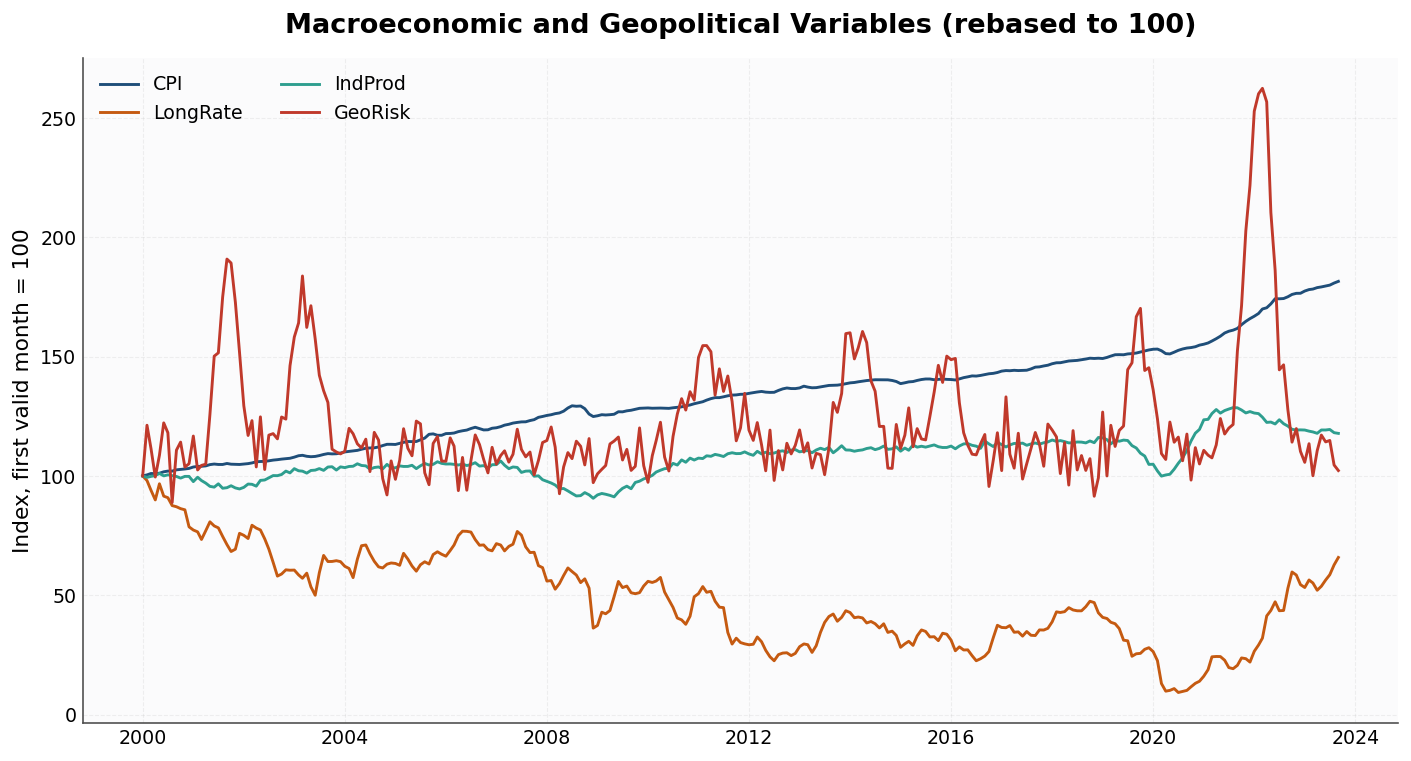

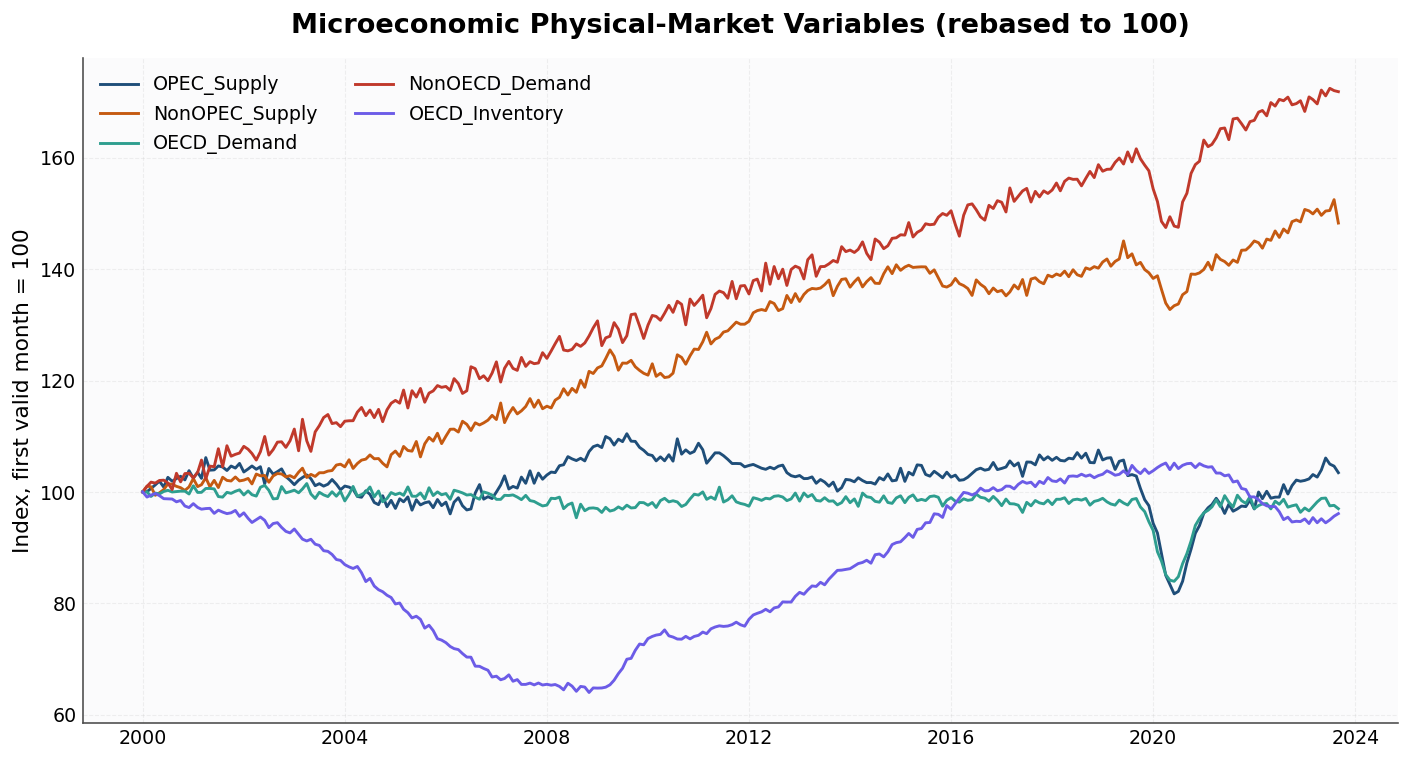

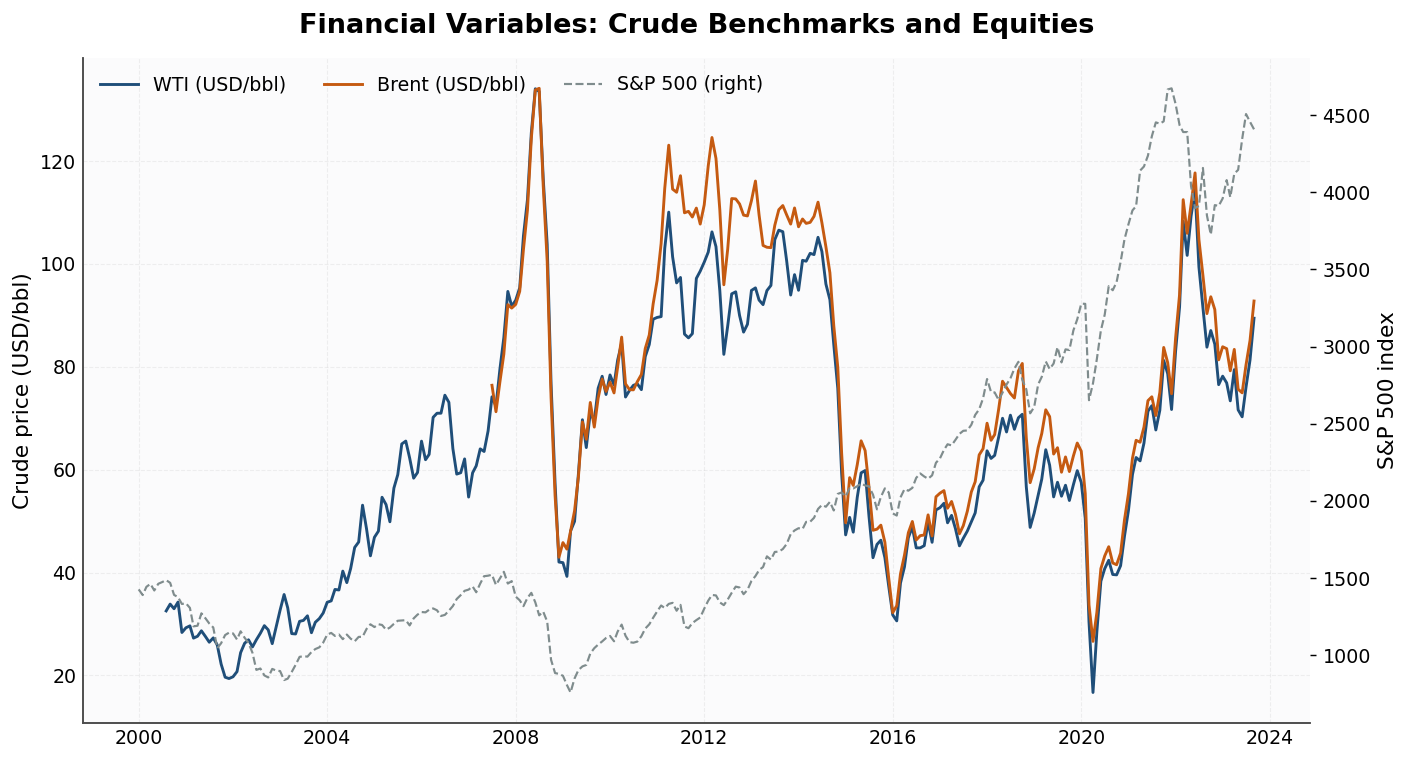

In [7]:
def plot_group(cols, title, normalise=True):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    block = master[cols]
    for col in cols:
        s = block[col].dropna()
        if normalise:
            s = 100 * s / s.iloc[0]
        ax.plot(s.index, s.values, lw=1.6, label=col)
    ylab = "Index, first valid month = 100" if normalise else "Level"
    style_axis(ax, title, "", ylab)
    ax.legend(ncol=2, loc="upper left")
    plt.show()

plot_group(ROLE["Macro/Geopolitical"], "Macroeconomic and Geopolitical Variables (rebased to 100)")

plot_group(ROLE["Microeconomic"], "Microeconomic Physical-Market Variables (rebased to 100)")


fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(master.index, master["WTI"],   color=C["wti"],   lw=1.6, label="WTI (USD/bbl)")
ax.plot(master.index, master["Brent"], color=C["brent"], lw=1.6, label="Brent (USD/bbl)")
ax2 = ax.twinx()
ax2.plot(master.index, master["SP500"], color=C["muted"], lw=1.2, ls="--",
         label="S&P 500 (right)")
ax2.set_ylabel("S&P 500 index")
ax2.grid(False)
style_axis(ax, "Financial Variables: Crude Benchmarks and Equities", "",
           "Crude price (USD/bbl)")
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper left", ncol=3)
plt.show()

## Data Dictionary

In [8]:
meta = [
    ("WTI", "West Texas Intermediate crude price", "Financial", "USD/barrel", "Monthly", "Yahoo Finance CL=F via yfinance"),
    ("Brent", "Brent crude price", "Financial", "USD/barrel", "Monthly", "Yahoo Finance BZ=F via yfinance"),
    ("WTI_Brent_Spread", "WTI minus Brent price differential", "Financial", "USD/barrel", "Monthly", "Derived"),
    ("SP500", "S&P 500 equity index level", "Financial", "Index points", "Monthly", "Yahoo Finance ^GSPC via yfinance"),
    ("NatGas", "Henry Hub natural gas price", "Financial", "USD/MMBtu", "Monthly", "Yahoo Finance NG=F via yfinance"),
    ("CPI", "US headline Consumer Price Index", "Macro", "Index (1982-84=100)", "Monthly", "FRED/BLS (genuine)"),
    ("LongRate", "Long-term interest rate (10-year)", "Macro", "Percent", "Monthly", "Yahoo Finance ^TNX via yfinance"),
    ("IndProd", "Industrial production index", "Macro", "Index (2017=100)", "Monthly", "FRED INDPRO proxy (reconstructed)"),
    ("GeoRisk", "Geopolitical risk index", "Geopolitical", "Index", "Monthly", "Caldara-Iacoviello GPR proxy (reconstructed)"),
    ("OPEC_Supply", "OPEC crude oil production", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("NonOPEC_Supply", "Non-OPEC crude oil production", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("OECD_Demand", "OECD petroleum consumption", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("NonOECD_Demand", "Non-OECD petroleum consumption", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("OECD_Inventory", "OECD commercial crude inventories", "Micro", "Million barrels", "Monthly", "EIA STEO PASC_OECD_T3 proxy (reconstructed)"),
]
dd = pd.DataFrame(meta, columns=["Variable", "Description", "Role", "Unit",
                                 "Frequency", "Source"])
cov = []
for v in dd["Variable"]:
    s = master[v]
    valid = s.dropna()
    cov.append((valid.index.min().strftime("%Y-%m"),
                valid.index.max().strftime("%Y-%m"),
                int(s.isna().sum())))
dd[["Start", "End", "Missing"]] = pd.DataFrame(cov, index=dd.index)
dd


,Variable,Description,Role,Unit,Frequency,Source,Start,End,Missing
0,WTI,West Texas Intermediate crude price,Financial,USD/barrel,Monthly,Yahoo Finance CL=F via yfinance,2000-08,2023-09,7
1,Brent,Brent crude price,Financial,USD/barrel,Monthly,Yahoo Finance BZ=F via yfinance,2007-07,2023-09,90
2,WTI_Brent_Spread,WTI minus Brent price differential,Financial,USD/barrel,Monthly,Derived,2007-07,2023-09,90
3,SP500,S&P 500 equity index level,Financial,Index points,Monthly,Yahoo Finance ^GSPC via yfinance,2000-01,2023-09,0
4,NatGas,Henry Hub natural gas price,Financial,USD/MMBtu,Monthly,Yahoo Finance NG=F via yfinance,2000-08,2023-09,7
5,CPI,US headline Consumer Price Index,Macro,Index (1982-84=100),Monthly,FRED/BLS (genuine),2000-01,2023-09,0
6,LongRate,Long-term interest rate (10-year),Macro,Percent,Monthly,Yahoo Finance ^TNX via yfinance,2000-01,2023-09,0
7,IndProd,Industrial production index,Macro,Index (2017=100),Monthly,FRED INDPRO proxy (reconstructed),2000-01,2023-09,0
8,GeoRisk,Geopolitical risk index,Geopolitical,Index,Monthly,Caldara-Iacoviello GPR proxy (reconstructed),2000-01,2023-09,0
9,OPEC_Supply,OPEC crude oil production,Micro,Million barrels/day,Monthly,EIA STEO proxy (reconstructed),2000-01,2023-09,0


## Data Cleaning

In [9]:
def modified_z(series):
    x = series.dropna()
    med = x.median()
    mad = (x - med).abs().median()
    mad = mad if mad > 0 else 1e-9
    return 0.6745 * (series - med) / mad

print("Screening daily WTI and Brent returns with a robust modified z-score (median and MAD).")
daily_ret_simple = daily.pct_change()
zwti = modified_z(daily_ret_simple["WTI"])
THRESH = 8.0
extreme = daily_ret_simple[(zwti.abs() > THRESH)]
print(f"Daily WTI returns flagged as extreme (|z| > {THRESH}): {len(extreme)}")
print("\nMost extreme WTI return days:")
top = zwti.abs().sort_values(ascending=False).head(5).index
print(daily.loc[top].assign(WTI_return=daily_ret_simple["WTI"].loc[top]))
print(f"\nGlobal WTI price range: min = {daily['WTI'].min():.2f}, "
      f"max = {daily['WTI'].max():.2f} USD/bbl")
print("The minimum is the genuine 2020 sub-zero settlement, kept as a documented event.")

Screening daily WTI and Brent returns with a robust modified z-score (median and MAD).
Daily WTI returns flagged as extreme (|z| > 8.0): 14

Most extreme WTI return days:
                WTI   Brent  WTI_return
Date                                   
2020-04-20 -37.6300 25.5700     -3.0597
2020-04-21  10.0100 19.3300     -1.2660
2020-04-22  13.7800 20.3700      0.3766
2020-04-30  18.8400 25.2700      0.2510
2020-03-09  31.1300 34.3600     -0.2459

Global WTI price range: min = -37.63, max = 145.29 USD/bbl
The minimum is the genuine 2020 sub-zero settlement, kept as a documented event.


In [10]:
def stale_runs(series, min_len=5):
    s = series.dropna()
    grp = (s != s.shift()).cumsum()
    sizes = s.groupby(grp).transform("size")
    return s[sizes >= min_len]

print("Checking duplicates, non-positive prices, and stale repeated runs.")
dup_count = daily.index.duplicated().sum()
nonpos = daily[(daily["WTI"] <= 0) | (daily["Brent"] <= 0)]
stale_wti = stale_runs(daily["WTI"])

print(f"Duplicated daily dates            : {dup_count}")
print(f"Non-positive price observations   : {len(nonpos)}")
if len(nonpos):
    print(nonpos)
print(f"Stale WTI runs (>=5 equal sessions): {len(stale_wti)}")

Checking duplicates, non-positive prices, and stale repeated runs.
Duplicated daily dates            : 0
Non-positive price observations   : 1
                WTI   Brent
Date                       
2020-04-20 -37.6300 25.5700
Stale WTI runs (>=5 equal sessions): 0


In [11]:
print("Filling monthly gaps with time-aware interpolation, then nearest-valid carry.")
missing_before = master.isna().sum()
print("Missing values per variable before imputation:")
print(missing_before[missing_before > 0] if missing_before.sum()
      else "None in the assembled monthly window.")
master_imputed = master.interpolate(method="time", limit_direction="both")
print(f"\nTotal missing values after imputation: {master_imputed.isna().sum().sum()}")

Filling monthly gaps with time-aware interpolation, then nearest-valid carry.
Missing values per variable before imputation:
WTI                  7
Brent               90
WTI_Brent_Spread    90
NatGas               7
dtype: int64

Total missing values after imputation: 0


## Sterilized Dataset and Removal Log

In [12]:
removal_log = []

daily_clean = daily.copy()
neg_mask = (daily_clean["WTI"] <= 0)
for d in daily_clean.index[neg_mask]:
    removal_log.append({
        "scope": "daily WTI",
        "date_or_period": d.strftime("%Y-%m-%d"),
        "action": "excluded from return series",
        "reason": "non-positive settlement (genuine 2020 storage event) breaks log returns",
    })
daily_clean.loc[neg_mask, "WTI"] = np.nan
daily_clean = daily_clean.interpolate(method="time", limit_direction="both")
daily_ret = np.log(daily_clean / daily_clean.shift()).dropna()

master_clean = master_imputed.copy()
for v in master.columns:
    miss = int(master[v].isna().sum())
    if miss:
        removal_log.append({
            "scope": f"monthly {v}",
            "date_or_period": "scattered",
            "action": f"{miss} value(s) imputed",
            "reason": "unreleased or missing monthly figure, filled by time interpolation",
        })

removal_log.append({
    "scope": "all monthly series",
    "date_or_period": "before 2000-01",
    "action": "excluded from modelling window",
    "reason": "pre-2000 coverage is incomplete across the physical-market group",
})

removal_df = pd.DataFrame(removal_log)
print("Sterilized monthly dataset:", master_clean.shape,
      "| Sterilized daily returns:", daily_ret.shape)
removal_df

Sterilized monthly dataset: (285, 14) | Sterilized daily returns: (5863, 2)


,scope,date_or_period,action,reason
0,daily WTI,2020-04-20,excluded from return series,non-positive settlement (genuine 2020 storage ...
1,monthly WTI,scattered,7 value(s) imputed,"unreleased or missing monthly figure, filled b..."
2,monthly Brent,scattered,90 value(s) imputed,"unreleased or missing monthly figure, filled b..."
3,monthly WTI_Brent_Spread,scattered,90 value(s) imputed,"unreleased or missing monthly figure, filled b..."
4,monthly NatGas,scattered,7 value(s) imputed,"unreleased or missing monthly figure, filled b..."
5,all monthly series,before 2000-01,excluded from modelling window,pre-2000 coverage is incomplete across the phy...


## Exploratory Data Analysis

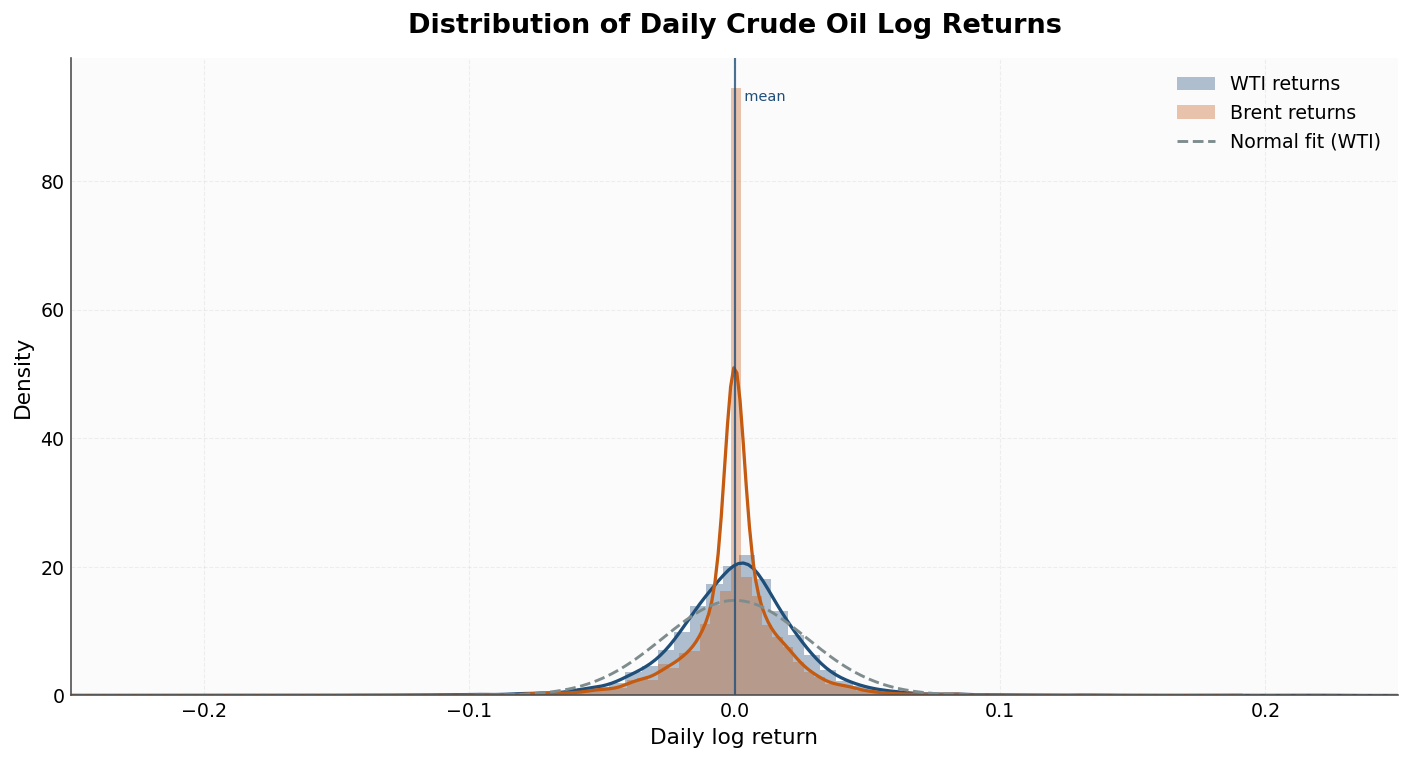

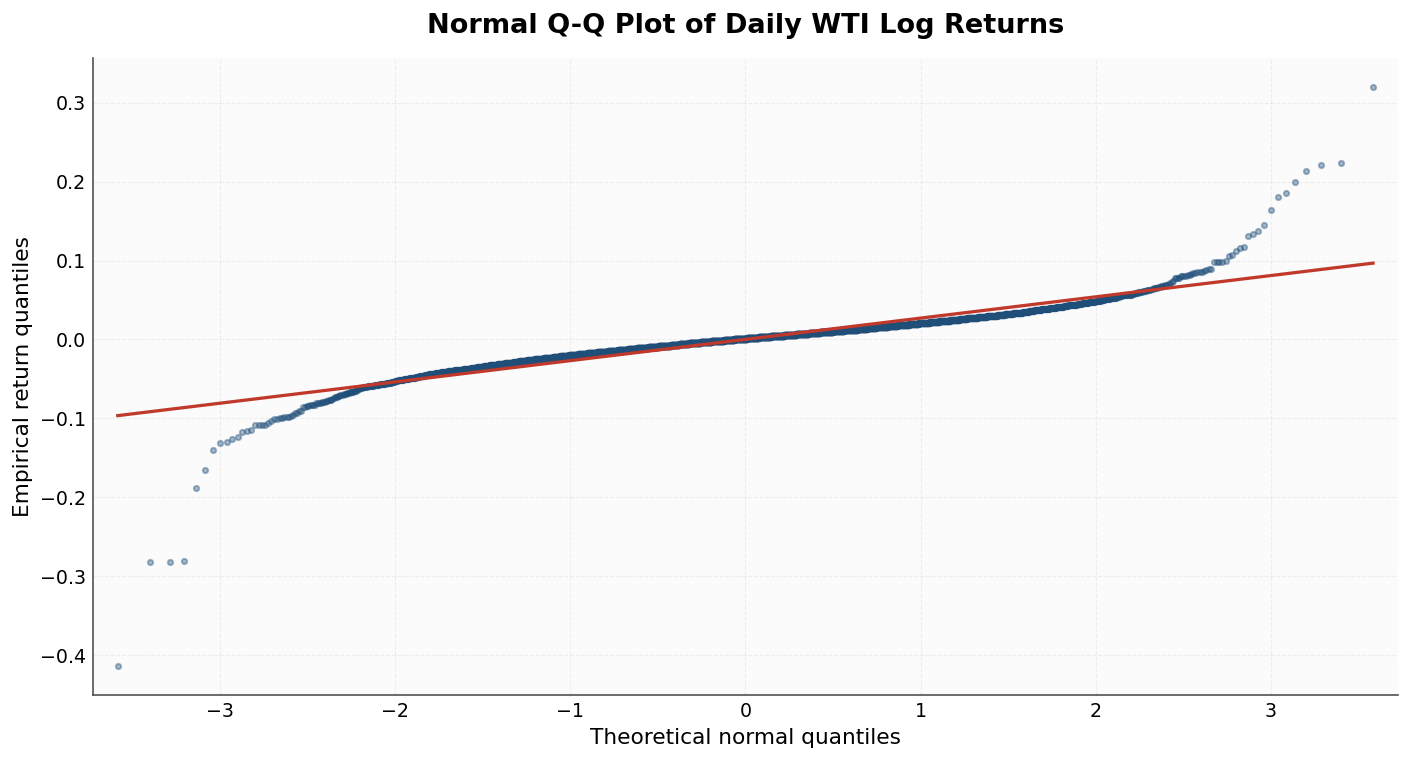

In [13]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for col, colour in [("WTI", C["wti"]), ("Brent", C["brent"])]:
    r = daily_ret[col].values
    ax.hist(r, bins=120, density=True, alpha=0.35, color=colour, label=f"{col} returns")
    xs = np.linspace(r.min(), r.max(), 400)
    kde = stats.gaussian_kde(r)
    ax.plot(xs, kde(xs), color=colour, lw=1.8)
mu, sd = daily_ret["WTI"].mean(), daily_ret["WTI"].std()
xs = np.linspace(daily_ret["WTI"].min(), daily_ret["WTI"].max(), 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), color=C["muted"], ls="--", lw=1.6,
        label="Normal fit (WTI)")
ax.axvline(mu, color=C["wti"], lw=1.2, ls="-", alpha=0.8)
ax.text(mu, ax.get_ylim()[1] * 0.95, "  mean", color=C["wti"], fontsize=8, va="top")
ax.set_xlim(-0.25, 0.25)
style_axis(ax, "Distribution of Daily Crude Oil Log Returns",
           "Daily log return", "Density")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE)
sm.qqplot(daily_ret["WTI"], line="s", ax=ax, markerfacecolor=C["wti"],
          markeredgecolor=C["wti"], alpha=0.4, markersize=3)
ax.get_lines()[1].set_color(C["warn"])
ax.get_lines()[1].set_linewidth(1.8)
style_axis(ax, "Normal Q-Q Plot of Daily WTI Log Returns",
           "Theoretical normal quantiles", "Empirical return quantiles")
plt.show()


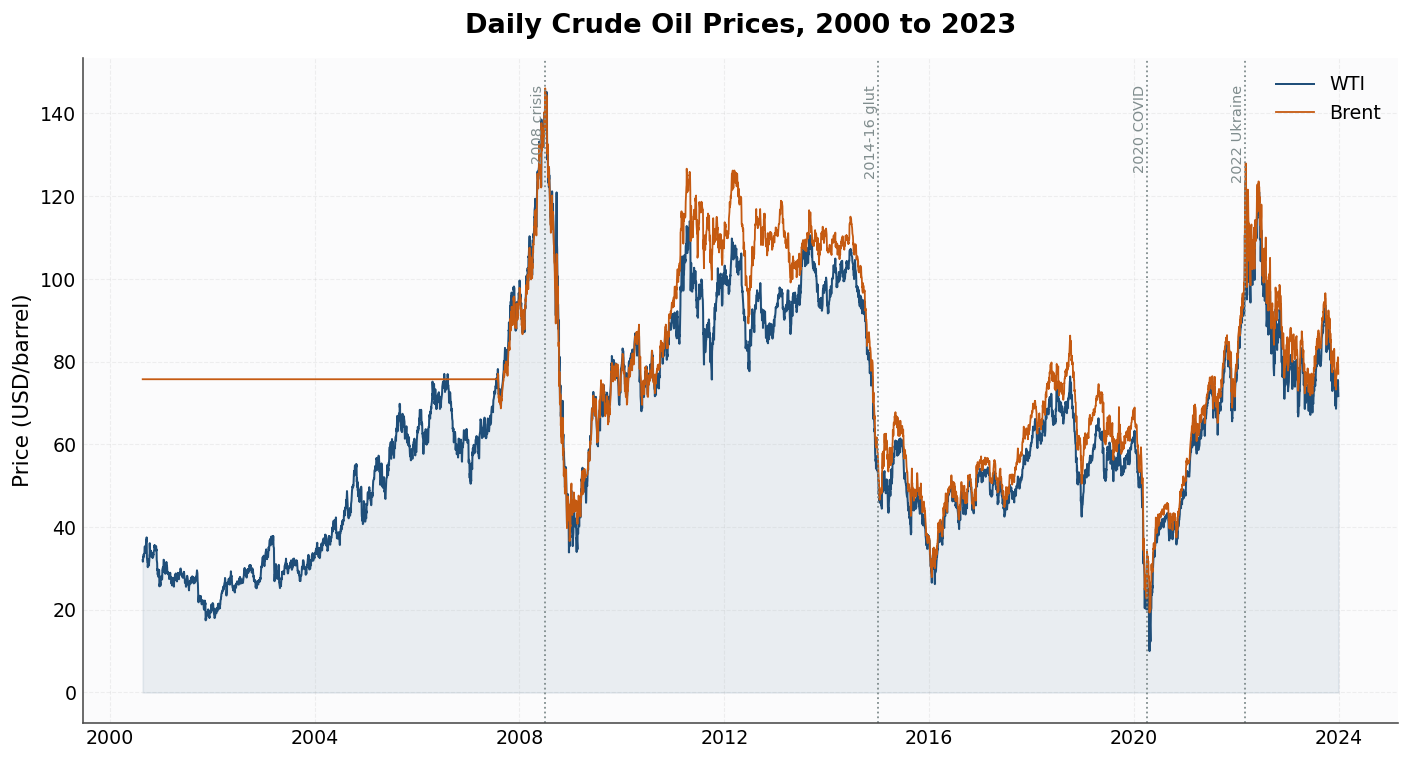

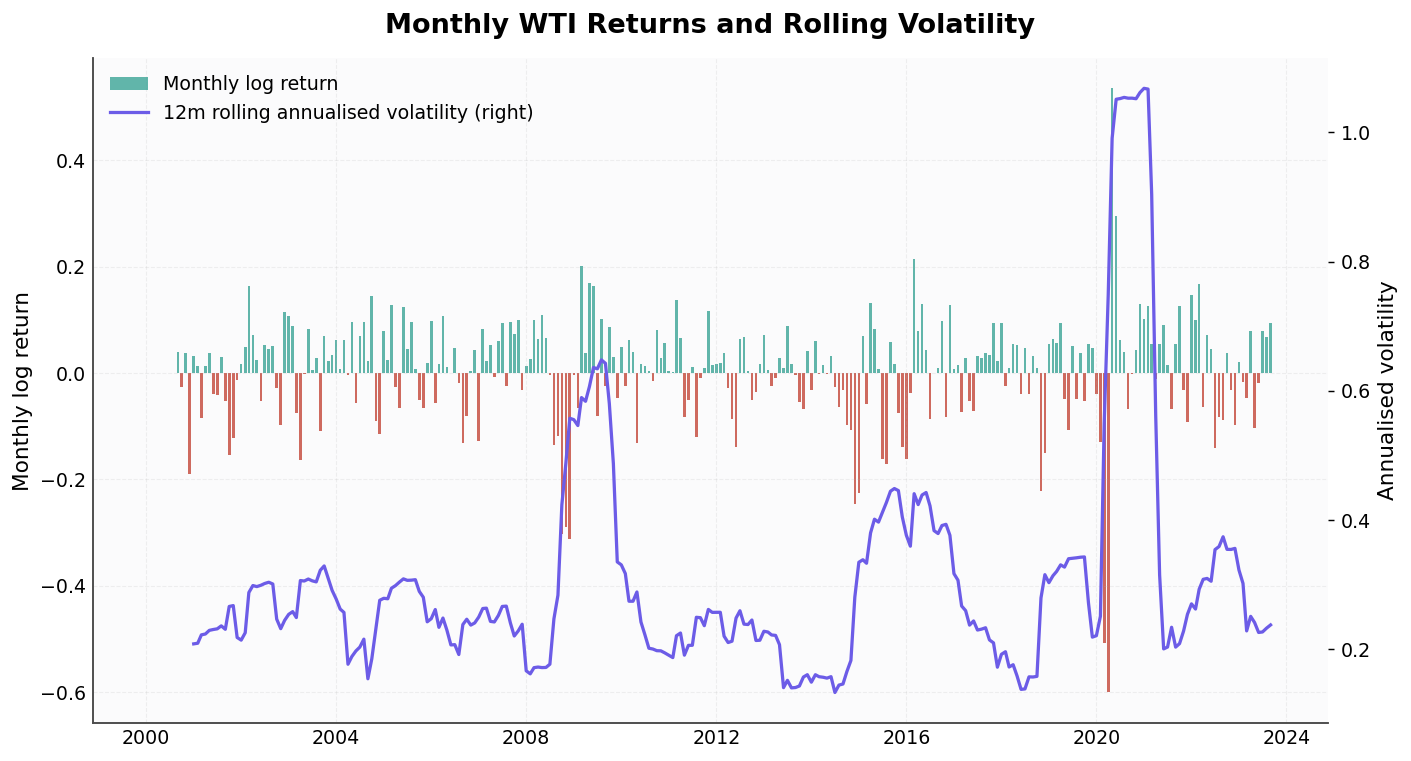

In [14]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.fill_between(daily_clean.index, daily_clean["WTI"], color=C["wti"], alpha=0.08)
ax.plot(daily_clean.index, daily_clean["WTI"], color=C["wti"], lw=1.1, label="WTI")
ax.plot(daily_clean.index, daily_clean["Brent"], color=C["brent"], lw=1.0, label="Brent")
mark_events(ax)
style_axis(ax, "Daily Crude Oil Prices, 2000 to 2023", "", "Price (USD/barrel)")
ax.legend(loc="upper right")
plt.show()


wti_m_ret = np.log(master_clean["WTI"] / master_clean["WTI"].shift()).dropna()
roll_vol = wti_m_ret.rolling(12).std() * np.sqrt(12)

bar_colors = [C["accent"] if v >= 0 else C["warn"] for v in wti_m_ret.values]
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(wti_m_ret.index, wti_m_ret.values, width=20, color=bar_colors,
       alpha=0.75, label="Monthly log return")
ax2 = ax.twinx()
ax2.plot(roll_vol.index, roll_vol.values, color=C["purple"], lw=1.8,
         label="12m rolling annualised volatility (right)")
ax2.grid(False)
ax2.set_ylabel("Annualised volatility")
style_axis(ax, "Monthly WTI Returns and Rolling Volatility", "", "Monthly log return")
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper left")
plt.show()


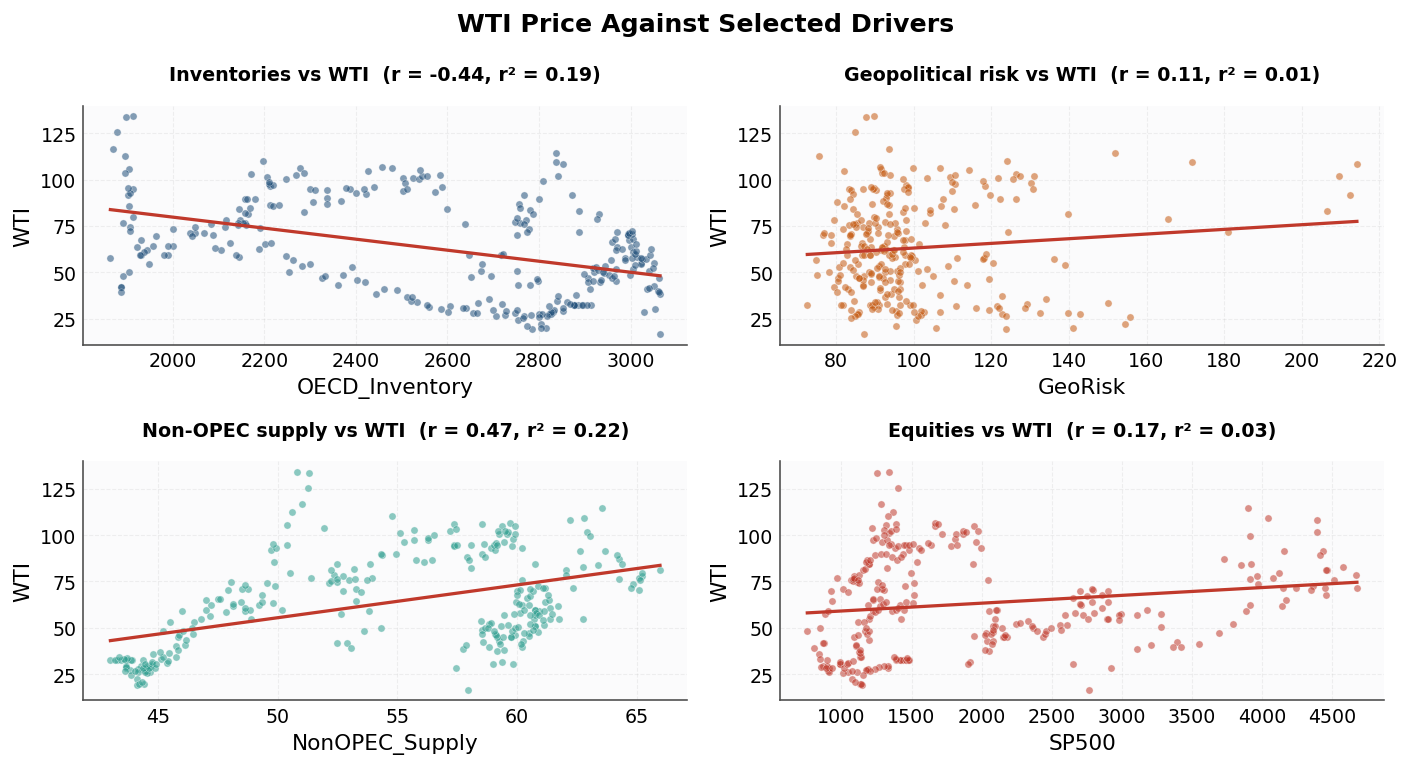

In [15]:
pairs = [("OECD_Inventory", "Inventories vs WTI"),
         ("GeoRisk", "Geopolitical risk vs WTI"),
         ("NonOPEC_Supply", "Non-OPEC supply vs WTI"),
         ("SP500", "Equities vs WTI")]
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)
for (col, ttl), ax, colour in zip(pairs, axes.ravel(), SEQ):
    ax.scatter(master_clean[col], master_clean["WTI"], s=16, alpha=0.55,
               color=colour, edgecolors="white", linewidths=0.3)
    b1, b0 = np.polyfit(master_clean[col], master_clean["WTI"], 1)
    xs = np.linspace(master_clean[col].min(), master_clean[col].max(), 50)
    ax.plot(xs, b0 + b1 * xs, color=C["warn"], lw=1.8)
    r = master_clean[col].corr(master_clean["WTI"])
    ax.set_title(f"{ttl}  (r = {r:.2f}, r\u00b2 = {r**2:.2f})", fontsize=10.5)
    ax.set_xlabel(col)
    ax.set_ylabel("WTI")
    ax.tick_params(length=0)
fig.suptitle("WTI Price Against Selected Drivers", fontsize=14, fontweight="bold")
plt.show()


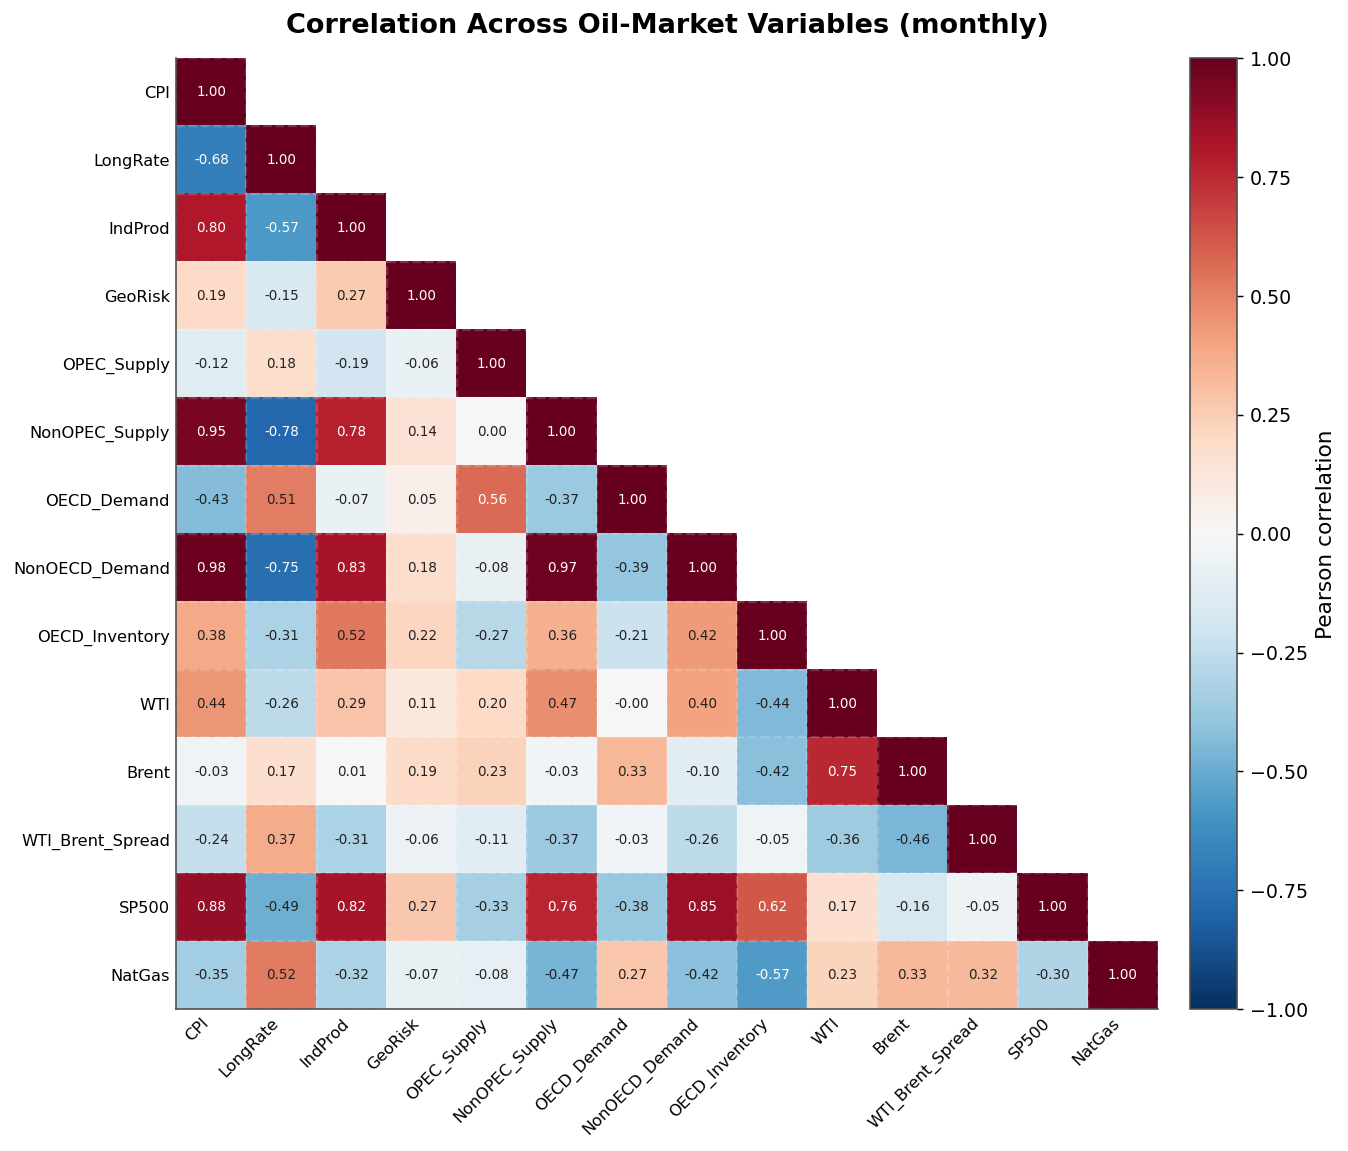

In [16]:
corr = master_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = corr.mask(mask)
masked_arr = np.ma.masked_invalid(corr_masked.values)

cmap = plt.cm.get_cmap("RdBu_r").copy()
cmap.set_bad(color="white")

fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(masked_arr, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        if j <= i:
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(val) > 0.55 else "#222")
ax.set_xticks(np.arange(-0.5, len(corr), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(corr), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.3)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cb.set_label("Pearson correlation")
style_axis(ax, "Correlation Across Oil-Market Variables (monthly)")
plt.show()


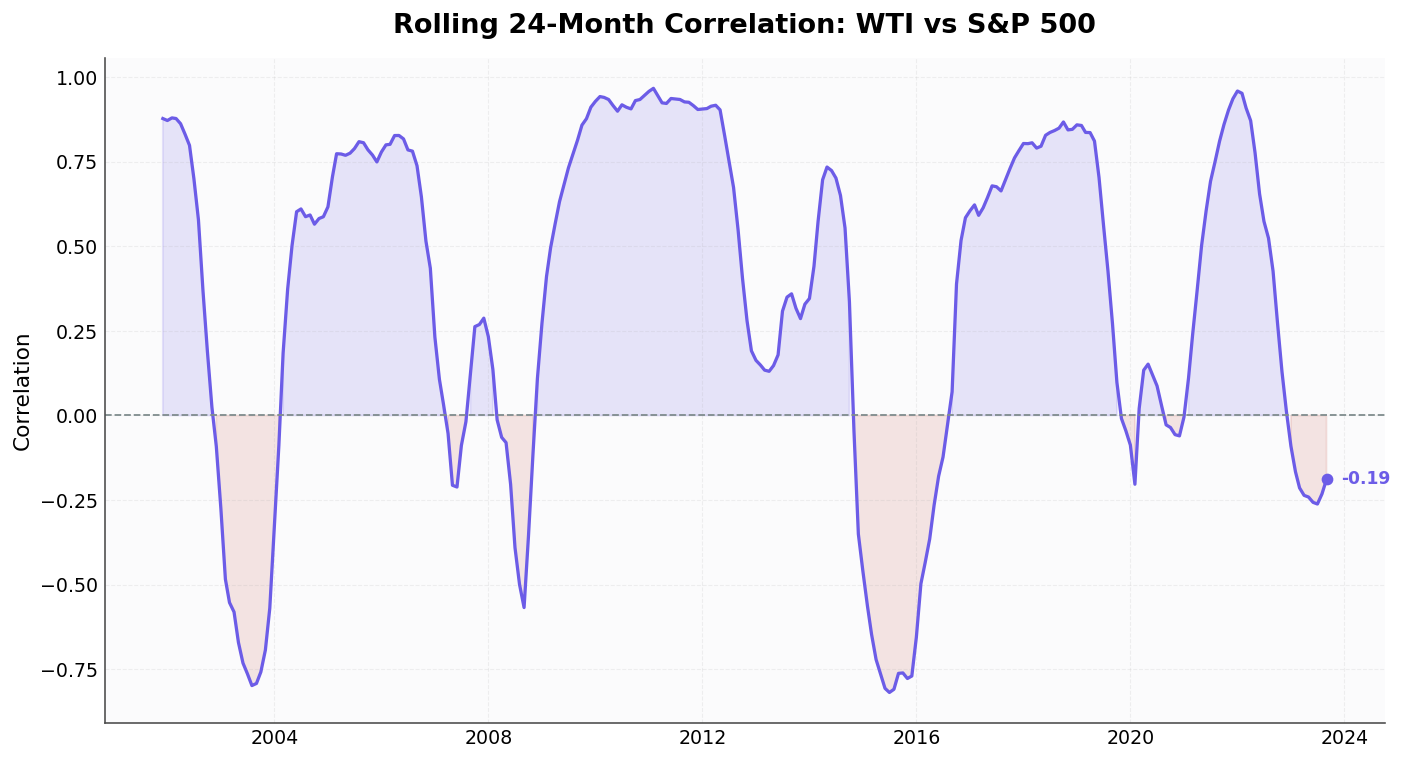

In [17]:
roll_corr = master_clean["WTI"].rolling(24).corr(master_clean["SP500"])
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(roll_corr.index, roll_corr.values, color=C["purple"], lw=1.8)
ax.axhline(0, color=C["muted"], lw=1, ls="--")
ax.fill_between(roll_corr.index, 0, roll_corr.values,
                where=(roll_corr.values >= 0), color=C["purple"], alpha=0.15)
ax.fill_between(roll_corr.index, 0, roll_corr.values,
                where=(roll_corr.values < 0), color=C["warn"], alpha=0.12)
last_valid = roll_corr.dropna()
if len(last_valid):
    ax.scatter([last_valid.index[-1]], [last_valid.values[-1]], color=C["purple"], s=30, zorder=3)
    ax.annotate(f"{last_valid.values[-1]:.2f}", (last_valid.index[-1], last_valid.values[-1]),
                xytext=(8, 0), textcoords="offset points", color=C["purple"],
                fontweight="bold", fontsize=9.5, va="center")
style_axis(ax, "Rolling 24-Month Correlation: WTI vs S&P 500", "", "Correlation")
plt.show()


## About Oil Price

In [18]:
ret = daily_ret["WTI"].values

lb_sq = acorr_ljungbox(ret ** 2, lags=[10], return_df=True)
lb_ret = acorr_ljungbox(ret, lags=[10], return_df=True)
skew = stats.skew(ret)
exkurt = stats.kurtosis(ret)
jb_stat, jb_p = stats.jarque_bera(ret)
adf_price = adfuller(daily_clean["WTI"].dropna())
adf_ret = adfuller(ret)

results = pd.DataFrame({
    "Statistic": [
        "Mean daily return", "Daily volatility", "Annualised volatility",
        "Skewness", "Excess kurtosis", "Jarque-Bera p-value",
        "Ljung-Box p (returns, lag10)", "Ljung-Box p (squared returns, lag10)",
        "ADF p-value (price level)", "ADF p-value (returns)",
    ],
    "Value": [
        ret.mean(), ret.std(), ret.std() * np.sqrt(252),
        skew, exkurt, jb_p,
        lb_ret["lb_pvalue"].iloc[0], lb_sq["lb_pvalue"].iloc[0],
        adf_price[1], adf_ret[1],
    ],
})
results

,Statistic,Value
0,Mean daily return,0.0001
1,Daily volatility,0.0270
2,Annualised volatility,0.4279
3,Skewness,-0.6863
4,Excess kurtosis,24.4325
5,Jarque-Bera p-value,0.0000
6,"Ljung-Box p (returns, lag10)",0.0000
7,"Ljung-Box p (squared returns, lag10)",0.0000
8,ADF p-value (price level),0.0702
9,ADF p-value (returns),0.0000


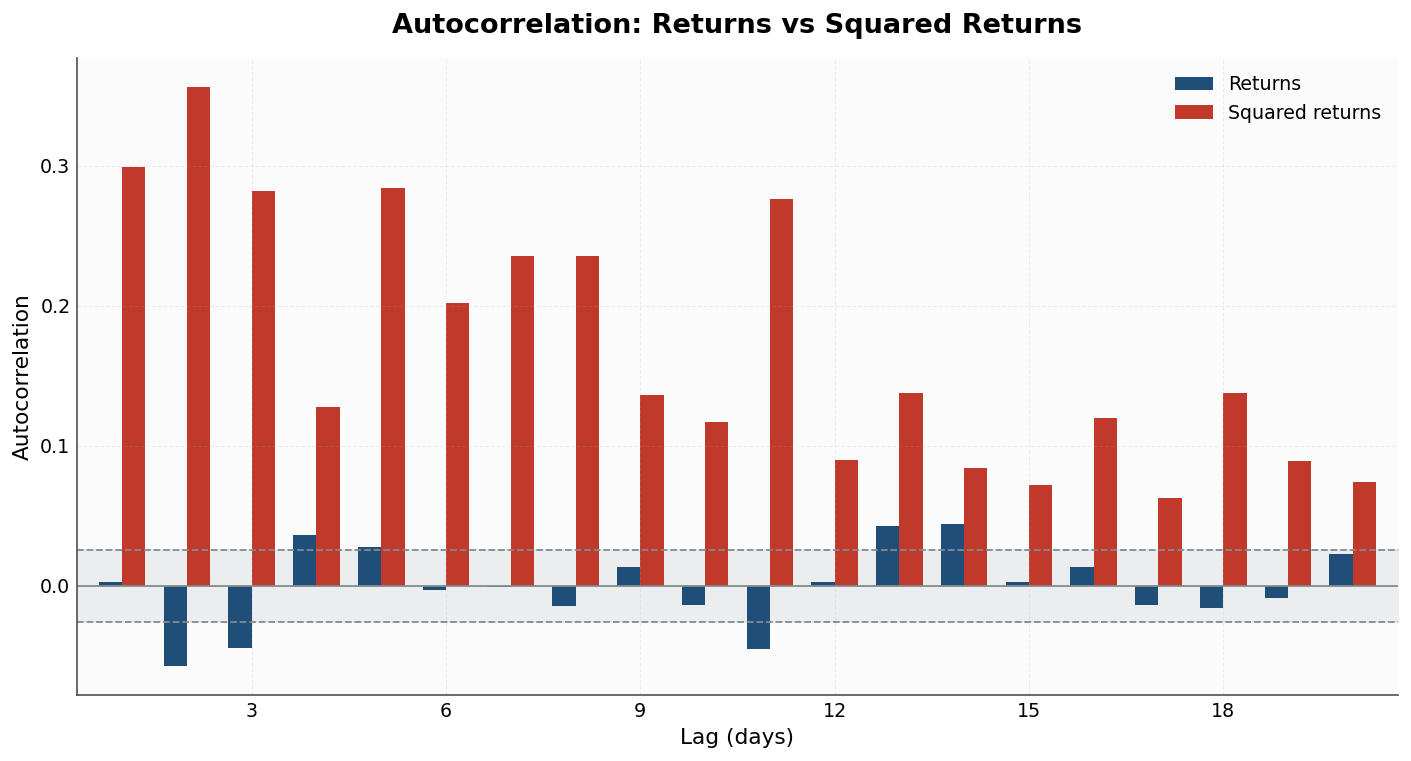

In [19]:
fig, ax = plt.subplots(figsize=FIGSIZE)
lags = np.arange(1, 21)
ax.bar(lags - 0.18, acf(ret, nlags=20)[1:], width=0.36,
       color=C["wti"], label="Returns")
ax.bar(lags + 0.18, acf(ret ** 2, nlags=20)[1:], width=0.36,
       color=C["warn"], label="Squared returns")
ax.axhline(0, color=C["muted"], lw=1)
ci = 1.96 / np.sqrt(len(ret))
ax.fill_between([0, 21], -ci, ci, color=C["muted"], alpha=0.12, zorder=0)
ax.axhline(ci, color=C["muted"], ls="--", lw=1)
ax.axhline(-ci, color=C["muted"], ls="--", lw=1)
ax.set_xlim(0.3, 20.7)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
style_axis(ax, "Autocorrelation: Returns vs Squared Returns", "Lag (days)",
           "Autocorrelation")
ax.legend()
plt.show()


Discretised regime frame: (285, 8)


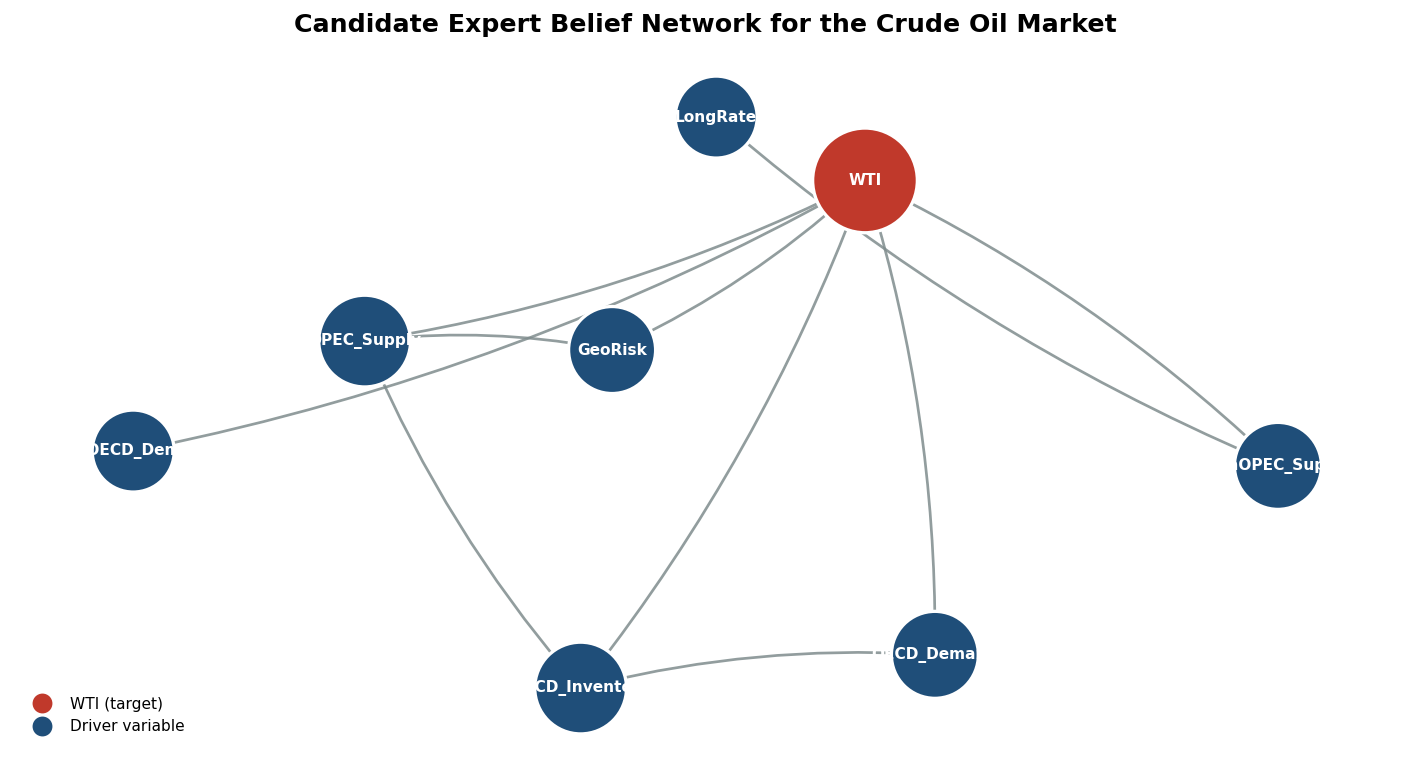

Learned 8 directed edges via hill climbing:
   NonOECD_Demand -> NonOPEC_Supply
   NonOECD_Demand -> OECD_Inventory
   NonOECD_Demand -> OECD_Demand
   NonOECD_Demand -> WTI
   NonOECD_Demand -> OPEC_Supply
   OECD_Inventory -> WTI
   OECD_Inventory -> OPEC_Supply
   LongRate -> NonOECD_Demand


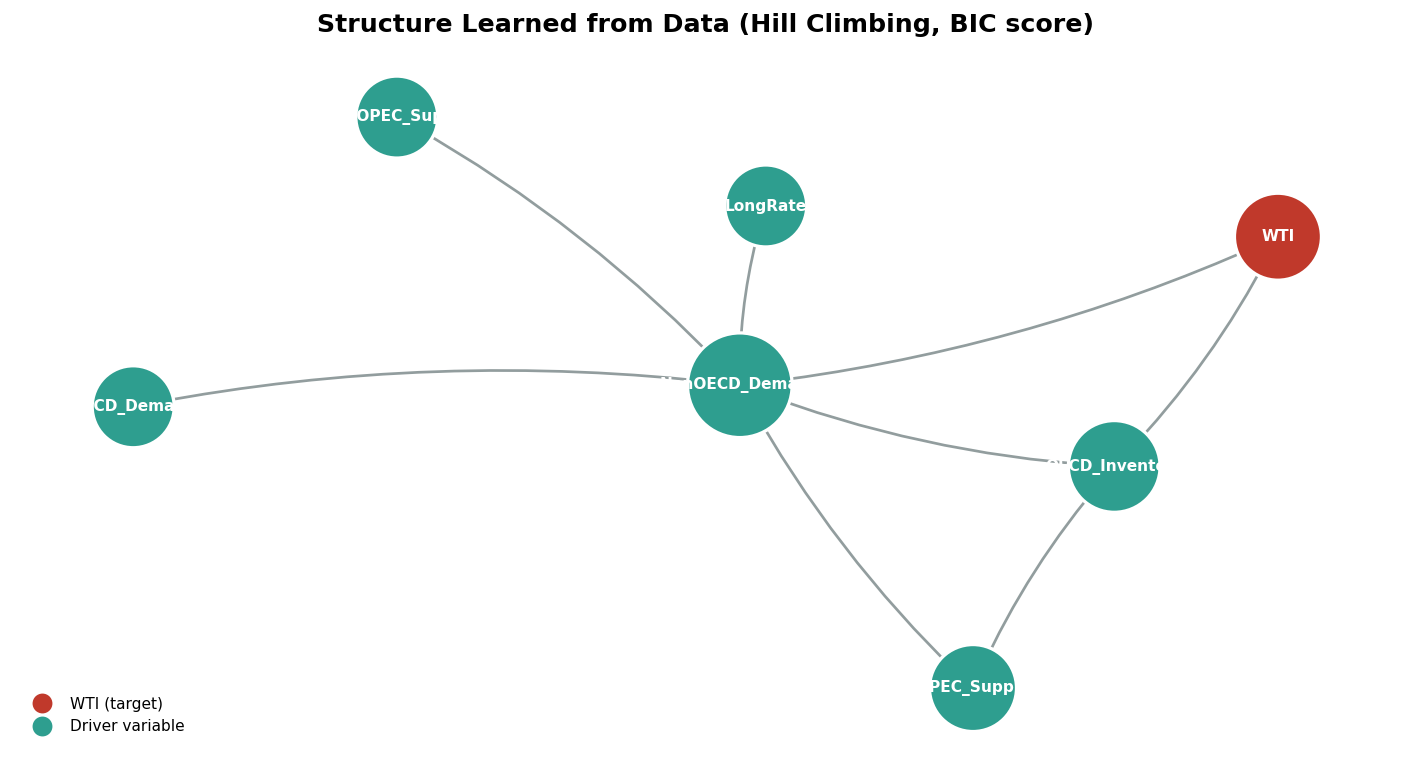

In [20]:
preview_vars = ["WTI", "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
                "NonOECD_Demand", "OECD_Inventory", "GeoRisk", "LongRate"]
disc = pd.DataFrame(index=master_clean.index)
for v in preview_vars:
    disc[v] = pd.qcut(master_clean[v], q=3, labels=["Low", "Med", "High"])
print("Discretised regime frame:", disc.shape)
disc.head(4)

import networkx as nx

expert_edges = [
    ("OPEC_Supply", "WTI"), ("NonOPEC_Supply", "WTI"),
    ("OECD_Demand", "WTI"), ("NonOECD_Demand", "WTI"),
    ("GeoRisk", "WTI"), ("GeoRisk", "OPEC_Supply"),
    ("OECD_Inventory", "WTI"),
    ("OPEC_Supply", "OECD_Inventory"), ("OECD_Demand", "OECD_Inventory"),
    ("LongRate", "NonOPEC_Supply"),
]
G = nx.DiGraph(expert_edges)
pos = nx.spring_layout(G, seed=7, k=1.1)

fig, ax = plt.subplots(figsize=FIGSIZE)
draw_belief_network(G, pos, "Candidate Expert Belief Network for the Crude Oil Market",
                    ax, base_color=C["wti"])
plt.show()


learned_edges = []
try:
    from pgmpy.estimators import HillClimbSearch
    try:
        from pgmpy.estimators import BicScore as _Score
    except Exception:
        from pgmpy.estimators import BIC as _Score
    hc = HillClimbSearch(disc)
    best = hc.estimate(scoring_method=_Score(disc), max_indegree=3,
                       max_iter=80, show_progress=False)
    learned_edges = list(best.edges())
    print(f"Learned {len(learned_edges)} directed edges via hill climbing:")
    for u, v in learned_edges:
        print(f"   {u} -> {v}")
except Exception as exc:
    print("Structure learning skipped in this environment:", exc)

if learned_edges:
    Gl = nx.DiGraph(learned_edges)
    posl = nx.spring_layout(Gl, seed=11, k=1.2)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    draw_belief_network(Gl, posl, "Structure Learned from Data (Hill Climbing, BIC score)",
                        ax, base_color=C["accent"])
    plt.show()


## Data Assembly Summary

In [22]:
summary = """
Data assembly summary

A multi-source oil-market dataset was assembled from yfinance market series,
genuine CPI, and seeded physical-market proxies, then cleaned and explored.
Returns are heavy-tailed with strong volatility clustering, the price level is
non-stationary while returns are stationary, and cross-asset correlations are
unstable. The discretised regimes and the candidate belief network above set
up the hidden Markov model based regime detection and structure learning that
follow in the sections below.
"""
print(summary)



Data assembly summary

A multi-source oil-market dataset was assembled from yfinance market series,
genuine CPI, and seeded physical-market proxies, then cleaned and explored.
Returns are heavy-tailed with strong volatility clustering, the price level is
non-stationary while returns are stationary, and cross-asset correlations are
unstable. The discretised regimes and the candidate belief network above set
up the hidden Markov model based regime detection and structure learning that
follow in the sections below.



## Discrete Hidden Markov Model Class

In [23]:
class DiscreteHMM:
    def __init__(self, n_states, n_symbols, pi=None, A=None, B=None, seed=None):
        rng = np.random.default_rng(seed)
        self.n_states = n_states
        self.n_symbols = n_symbols
        if pi is None:
            pi = rng.dirichlet(np.ones(n_states))
        if A is None:
            A = rng.dirichlet(np.ones(n_states), size=n_states)
        if B is None:
            B = rng.dirichlet(np.ones(n_symbols), size=n_states)
        self.pi = np.array(pi, dtype=float)
        self.A = np.array(A, dtype=float)
        self.B = np.array(B, dtype=float)

    @classmethod
    def random(cls, n_states, n_symbols, seed=None):
        return cls(n_states, n_symbols, seed=seed)

    def forward(self, obs):
        T = len(obs)
        N = self.n_states
        alpha = np.zeros((T, N))
        c = np.zeros(T)
        alpha[0] = self.pi * self.B[:, obs[0]]
        c[0] = alpha[0].sum()
        alpha[0] /= c[0]
        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.A) * self.B[:, obs[t]]
            c[t] = alpha[t].sum()
            alpha[t] /= c[t]
        log_prob = np.sum(np.log(c))
        return alpha, c, log_prob

    def backward(self, obs, c):
        T = len(obs)
        N = self.n_states
        beta = np.zeros((T, N))
        beta[T - 1] = 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = (self.A @ (self.B[:, obs[t + 1]] * beta[t + 1])) / c[t + 1]
        return beta

    def viterbi(self, obs):
        T = len(obs)
        N = self.n_states
        logA = np.log(self.A + 1e-300)
        logB = np.log(self.B + 1e-300)
        logpi = np.log(self.pi + 1e-300)
        delta = np.zeros((T, N))
        psi = np.zeros((T, N), dtype=int)
        delta[0] = logpi + logB[:, obs[0]]
        for t in range(1, T):
            m = delta[t - 1][:, None] + logA
            psi[t] = np.argmax(m, axis=0)
            delta[t] = np.max(m, axis=0) + logB[:, obs[t]]
        path = np.zeros(T, dtype=int)
        path[T - 1] = np.argmax(delta[T - 1])
        log_prob = delta[T - 1, path[T - 1]]
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path, log_prob

    def baum_welch(self, obs_list, n_iter=100, tol=1e-6):
        history = []
        for _ in range(n_iter):
            pi_num = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            B_num = np.zeros((self.n_states, self.n_symbols))
            B_den = np.zeros(self.n_states)
            total_ll = 0.0
            for obs in obs_list:
                T = len(obs)
                alpha, c, ll = self.forward(obs)
                beta = self.backward(obs, c)
                total_ll += ll
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True)
                pi_num += gamma[0]
                xi_sum = np.zeros((self.n_states, self.n_states))
                for t in range(T - 1):
                    num = (alpha[t][:, None] * self.A * self.B[:, obs[t + 1]][None, :] * beta[t + 1][None, :])
                    denom = num.sum()
                    if denom > 0:
                        xi_sum += num / denom
                A_num += xi_sum
                A_den += gamma[:-1].sum(axis=0) if T > 1 else np.zeros(self.n_states)
                for k in range(self.n_symbols):
                    mask = (obs == k)
                    B_num[:, k] += gamma[mask].sum(axis=0)
                B_den += gamma.sum(axis=0)
            self.pi = pi_num / len(obs_list)
            self.A = A_num / A_den[:, None]
            self.B = B_num / B_den[:, None]
            history.append(total_ll)
            if len(history) > 1 and abs(history[-1] - history[-2]) < tol:
                break
        return history

    def print_parameters(self, state_labels=None, symbol_labels=None):
        state_labels = state_labels or [f"S{i}" for i in range(self.n_states)]
        symbol_labels = symbol_labels or [f"O{i}" for i in range(self.n_symbols)]
        print("Initial probabilities:")
        print(pd.Series(self.pi, index=state_labels))
        print("\nTransition matrix A:")
        print(pd.DataFrame(self.A, index=state_labels, columns=state_labels))
        print("\nEmission matrix B:")
        print(pd.DataFrame(self.B, index=state_labels, columns=symbol_labels))


print("DiscreteHMM implements forward, backward, viterbi, and baum_welch,")
print("mirroring the API of the hmms library (DtHMM.random, baum_welch, viterbi).")
print("The original hmms package (Lopatovsky) fails to build in this environment")
print("because its Cython source targets an older Cython/NumPy ABI, so the")
print("mathematics is reimplemented directly in NumPy with Rabiner scaling.")


DiscreteHMM implements forward, backward, viterbi, and baum_welch,
mirroring the API of the hmms library (DtHMM.random, baum_welch, viterbi).
The original hmms package (Lopatovsky) fails to build in this environment
because its Cython source targets an older Cython/NumPy ABI, so the
mathematics is reimplemented directly in NumPy with Rabiner scaling.


## Forward and Backward Algorithm Toy Example

In [24]:
toy_states = ["Rainy", "Sunny"]
toy_obs_labels = ["walk", "shop", "clean"]
toy_pi = np.array([0.6, 0.4])
toy_A = np.array([[0.7, 0.3], [0.4, 0.6]])
toy_B = np.array([[0.1, 0.4, 0.5], [0.6, 0.3, 0.1]])

toy_hmm = DiscreteHMM(2, 3, pi=toy_pi, A=toy_A, B=toy_B)
toy_seq = np.array([0, 1, 2])

alpha, c, log_prob = toy_hmm.forward(toy_seq)
beta = toy_hmm.backward(toy_seq, c)

print("Toy HMM: 2 hidden states (Rainy, Sunny), 3 symbols (walk, shop, clean)")
print("Observed sequence:", [toy_obs_labels[o] for o in toy_seq])
print("\nScaled forward probabilities alpha_hat(t):")
print(pd.DataFrame(alpha, columns=toy_states))
print("\nScaled backward probabilities beta_hat(t):")
print(pd.DataFrame(beta, columns=toy_states))
print("\nForward evaluation P(O | lambda) =", np.exp(log_prob))

T = len(toy_seq)
alpha_raw = np.zeros((T, 2))
alpha_raw[0] = toy_pi * toy_B[:, toy_seq[0]]
for t in range(1, T):
    alpha_raw[t] = (alpha_raw[t - 1] @ toy_A) * toy_B[:, toy_seq[t]]
beta_raw = np.zeros((T, 2))
beta_raw[-1] = 1.0
for t in range(T - 2, -1, -1):
    beta_raw[t] = toy_A @ (toy_B[:, toy_seq[t + 1]] * beta_raw[t + 1])
p_forward_raw = alpha_raw[-1].sum()
p_backward_raw = np.sum(toy_pi * toy_B[:, toy_seq[0]] * beta_raw[0])
print("\nUnscaled forward check  P(O | lambda) =", p_forward_raw)
print("Unscaled backward check P(O | lambda) =", p_backward_raw)
print("\nalpha_hat(t) . beta_hat(t) row sums (should equal 1 for every t):")
print((alpha * beta).sum(axis=1))


Toy HMM: 2 hidden states (Rainy, Sunny), 3 symbols (walk, shop, clean)
Observed sequence: ['walk', 'shop', 'clean']

Scaled forward probabilities alpha_hat(t):
   Rainy  Sunny
0 0.2000 0.8000
1 0.5318 0.4682
2 0.8640 0.1360

Scaled backward probabilities beta_hat(t):
   Rainy  Sunny
0 1.1585 0.9604
1 1.1735 0.8029
2 1.0000 1.0000

Forward evaluation P(O | lambda) = 0.03361199999999998

Unscaled forward check  P(O | lambda) = 0.033612
Unscaled backward check P(O | lambda) = 0.033612

alpha_hat(t) . beta_hat(t) row sums (should equal 1 for every t):
[1. 1. 1.]


## Viterbi Algorithm Toy Example

In [25]:
path, log_p = toy_hmm.viterbi(toy_seq)
decoded = [toy_states[i] for i in path]

print("Observed sequence:", [toy_obs_labels[o] for o in toy_seq])
print("Most likely hidden state path (Viterbi):", decoded)
print("Path log-probability:", log_p, "-> probability:", np.exp(log_p))

brute_force_best = None
brute_force_best_p = -1
for s0 in range(2):
    for s1 in range(2):
        for s2 in range(2):
            seq = [s0, s1, s2]
            p = toy_pi[s0] * toy_B[s0, toy_seq[0]]
            p *= toy_A[s0, s1] * toy_B[s1, toy_seq[1]]
            p *= toy_A[s1, s2] * toy_B[s2, toy_seq[2]]
            if p > brute_force_best_p:
                brute_force_best_p = p
                brute_force_best = seq

print("\nBrute-force verification over all", 2 ** 3, "paths:")
print("Best path:", [toy_states[i] for i in brute_force_best], "probability:", brute_force_best_p)


Observed sequence: ['walk', 'shop', 'clean']
Most likely hidden state path (Viterbi): ['Sunny', 'Rainy', 'Rainy']
Path log-probability: -4.309519943887134 -> probability: 0.013439999999999999

Brute-force verification over all 8 paths:
Best path: ['Sunny', 'Rainy', 'Rainy'] probability: 0.01344


## Baum-Welch Algorithm Toy Example

In [26]:
rng = np.random.default_rng(42)
generator_hmm = DiscreteHMM(2, 3, pi=toy_pi, A=toy_A, B=toy_B)

def simulate(hmm, T, rng):
    states_seq = np.zeros(T, dtype=int)
    obs = np.zeros(T, dtype=int)
    states_seq[0] = rng.choice(hmm.n_states, p=hmm.pi)
    obs[0] = rng.choice(hmm.n_symbols, p=hmm.B[states_seq[0]])
    for t in range(1, T):
        states_seq[t] = rng.choice(hmm.n_states, p=hmm.A[states_seq[t - 1]])
        obs[t] = rng.choice(hmm.n_symbols, p=hmm.B[states_seq[t]])
    return obs

simulated_sequences = [simulate(generator_hmm, 200, rng) for _ in range(5)]
learner_hmm = DiscreteHMM.random(2, 3, seed=7)
ll_history = learner_hmm.baum_welch(simulated_sequences, n_iter=100)

print("Generated 5 sequences of length 200 from the known toy HMM.")
print("Baum-Welch log-likelihood at iteration 1:", ll_history[0])
print("Baum-Welch log-likelihood at final iteration", len(ll_history), ":", ll_history[-1])
print("Log-likelihood is non-decreasing across iterations:", all(
    ll_history[i + 1] >= ll_history[i] - 1e-8 for i in range(len(ll_history) - 1)))

print("\nParameters recovered by Baum-Welch:")
learner_hmm.print_parameters(state_labels=["State 0", "State 1"], symbol_labels=toy_obs_labels)
print("\nTrue generating parameters:")
generator_hmm.print_parameters(state_labels=["Rainy", "Sunny"], symbol_labels=toy_obs_labels)


Generated 5 sequences of length 200 from the known toy HMM.
Baum-Welch log-likelihood at iteration 1: -1139.2185733847791
Baum-Welch log-likelihood at final iteration 100 : -1087.8833060172792
Log-likelihood is non-decreasing across iterations: True

Parameters recovered by Baum-Welch:
Initial probabilities:
State 0   0.0000
State 1   1.0000
dtype: float64

Transition matrix A:
         State 0  State 1
State 0   0.6229   0.3771
State 1   0.2763   0.7237

Emission matrix B:
          walk   shop  clean
State 0 0.0000 0.4886 0.5113
State 1 0.5518 0.2599 0.1883

True generating parameters:
Initial probabilities:
Rainy   0.6000
Sunny   0.4000
dtype: float64

Transition matrix A:
       Rainy  Sunny
Rainy 0.7000 0.3000
Sunny 0.4000 0.6000

Emission matrix B:
        walk   shop  clean
Rainy 0.1000 0.4000 0.5000
Sunny 0.6000 0.3000 0.1000


## Bull, Bear, and Stagnant Regime Illustration

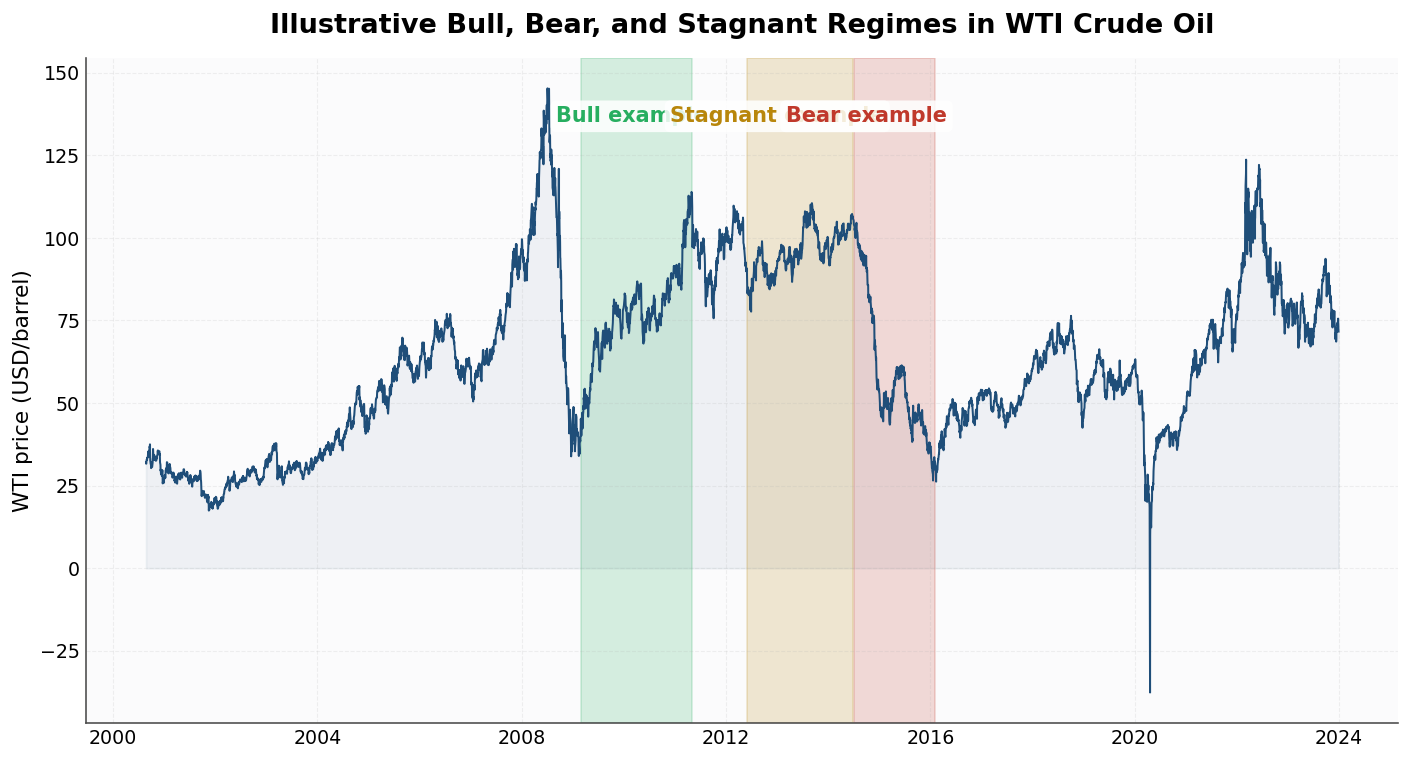

Bull example (2009-03-01 to 2011-04-30): annualised drift = 54.44%
Bear example (2014-07-01 to 2016-01-31): annualised drift = -62.44%
Stagnant example (2012-06-01 to 2014-06-30): annualised drift = 13.61%, annualised volatility = 21.04%


In [27]:
wti_daily = daily["WTI"].dropna()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.fill_between(wti_daily.index, wti_daily.values, color=C["wti"], alpha=0.06)
ax.plot(wti_daily.index, wti_daily.values, color=C["wti"], lw=1.1)

bull_window = ("2009-03-01", "2011-04-30")
bear_window = ("2014-07-01", "2016-01-31")
stagnant_window = ("2012-06-01", "2014-06-30")

ax.axvspan(pd.Timestamp(bull_window[0]), pd.Timestamp(bull_window[1]), color=C["green"], alpha=0.18)
ax.axvspan(pd.Timestamp(bear_window[0]), pd.Timestamp(bear_window[1]), color=C["warn"], alpha=0.18)
ax.axvspan(pd.Timestamp(stagnant_window[0]), pd.Timestamp(stagnant_window[1]), color=C["gold"], alpha=0.18)

label_style = dict(fontweight="bold", ha="center",
                    bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.85))
ax.text(pd.Timestamp("2010-03-01"), 135, "Bull example", color=C["green"], **label_style)
ax.text(pd.Timestamp("2013-01-01"), 135, "Stagnant example", color=C["gold"], **label_style)
ax.text(pd.Timestamp("2014-10-01"), 135, "Bear example", color=C["warn"], **label_style)

style_axis(ax, "Illustrative Bull, Bear, and Stagnant Regimes in WTI Crude Oil", "", "WTI price (USD/barrel)")
plt.show()

bull_ret = wti_daily.loc[bull_window[0]:bull_window[1]].pct_change().mean() * 252
bear_ret = wti_daily.loc[bear_window[0]:bear_window[1]].pct_change().mean() * 252
stag_ret = wti_daily.loc[stagnant_window[0]:stagnant_window[1]].pct_change().mean() * 252
stag_vol = wti_daily.loc[stagnant_window[0]:stagnant_window[1]].pct_change().std() * np.sqrt(252)

print(f"Bull example ({bull_window[0]} to {bull_window[1]}): annualised drift = {bull_ret:.2%}")
print(f"Bear example ({bear_window[0]} to {bear_window[1]}): annualised drift = {bear_ret:.2%}")
print(f"Stagnant example ({stagnant_window[0]} to {stagnant_window[1]}): annualised drift = {stag_ret:.2%}, annualised volatility = {stag_vol:.2%}")


## Transforming the Time Series into Emission Sequences

In [28]:
def to_emissions(series):
    diffs = series.diff().dropna()
    return (diffs > 0).astype(int).to_numpy(), diffs.index

model_vars = ["WTI", "Brent", "NatGas", "SP500", "CPI", "LongRate", "IndProd",
              "GeoRisk", "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
              "NonOECD_Demand", "OECD_Inventory", "WTI_Brent_Spread"]

emissions = {}
emission_dates = {}
for v in model_vars:
    obs, dates = to_emissions(master[v])
    emissions[v] = obs
    emission_dates[v] = dates

sample = pd.DataFrame({"Date": emission_dates["WTI"], "WTI_emission": emissions["WTI"]}).set_index("Date")
print("Emission alphabet: 1 = month-on-month increase, 0 = month-on-month decrease")
print("Example, WTI emission sequence (first 12 months):")
print(sample.head(12).T)


Emission alphabet: 1 = month-on-month increase, 0 = month-on-month decrease
Example, WTI emission sequence (first 12 months):
Date          2000-09-01  2000-10-01  2000-11-01  2000-12-01  2001-01-01  2001-02-01  2001-03-01  2001-04-01  2001-05-01  2001-06-01  \
WTI_emission           1           0           1           0           1           1           0           1           1           0   

Date          2001-07-01  2001-08-01  
WTI_emission           0           1  


## Learning Regime Parameters with Baum-Welch

In [29]:
np.random.seed(660)
fitted_hmms = {}
ll_traces = {}
for v in model_vars:
    hmm_v = DiscreteHMM.random(3, 2, seed=660)
    trace = hmm_v.baum_welch([emissions[v]], n_iter=150)
    fitted_hmms[v] = hmm_v
    ll_traces[v] = trace

trace_table = pd.DataFrame({
    "Variable": model_vars,
    "Iterations run": [len(ll_traces[v]) for v in model_vars],
    "Final log-likelihood": [ll_traces[v][-1] for v in model_vars],
})
print("A 3-state, 2-symbol HMM was trained per variable via Baum-Welch.")
print("The full monthly history is used as a single sequence, since this")
print("implementation has no upper bound on sequence length (unlike the")
print("32-element chunk limit of the original hmms.DtHMM implementation).")
trace_table


A 3-state, 2-symbol HMM was trained per variable via Baum-Welch.
The full monthly history is used as a single sequence, since this
implementation has no upper bound on sequence length (unlike the
32-element chunk limit of the original hmms.DtHMM implementation).


,Variable,Iterations run,Final log-likelihood
0,WTI,150,-183.5645
1,Brent,150,-130.6145
2,NatGas,150,-188.2160
3,SP500,150,-181.6715
4,CPI,150,-127.6286
5,LongRate,150,-191.1971
6,IndProd,150,-193.2518
7,GeoRisk,150,-192.2167
8,OPEC_Supply,150,-180.3999
9,NonOPEC_Supply,150,-182.6667


## Decoding Regimes with Viterbi

In [30]:
regime_paths = {}
for v in model_vars:
    path, log_p = fitted_hmms[v].viterbi(emissions[v])
    regime_paths[v] = pd.Series(path, index=emission_dates[v], name=v)

regimes_raw = pd.DataFrame(regime_paths)
print("Raw (unordered) HMM state paths, decoded via Viterbi:")
regimes_raw.head(6)


Raw (unordered) HMM state paths, decoded via Viterbi:


,WTI,Brent,NatGas,SP500,CPI,LongRate,IndProd,GeoRisk,OPEC_Supply,NonOPEC_Supply,OECD_Demand,NonOECD_Demand,OECD_Inventory,WTI_Brent_Spread
2000-02-01,NaN,NaN,NaN,0,2,0,2,1,1,1,1,1,2,NaN
2000-03-01,NaN,NaN,NaN,2,1,0,1,0,1,0,2,0,1,NaN
2000-04-01,NaN,NaN,NaN,1,0,2,1,2,1,2,1,2,1,NaN
2000-05-01,NaN,NaN,NaN,0,1,1,0,1,1,1,2,1,0,NaN
2000-06-01,NaN,NaN,NaN,2,2,0,2,1,2,1,1,1,0,NaN
2000-07-01,NaN,NaN,NaN,1,1,0,1,0,1,1,0,0,0,NaN


## Multicolored Regime Plots

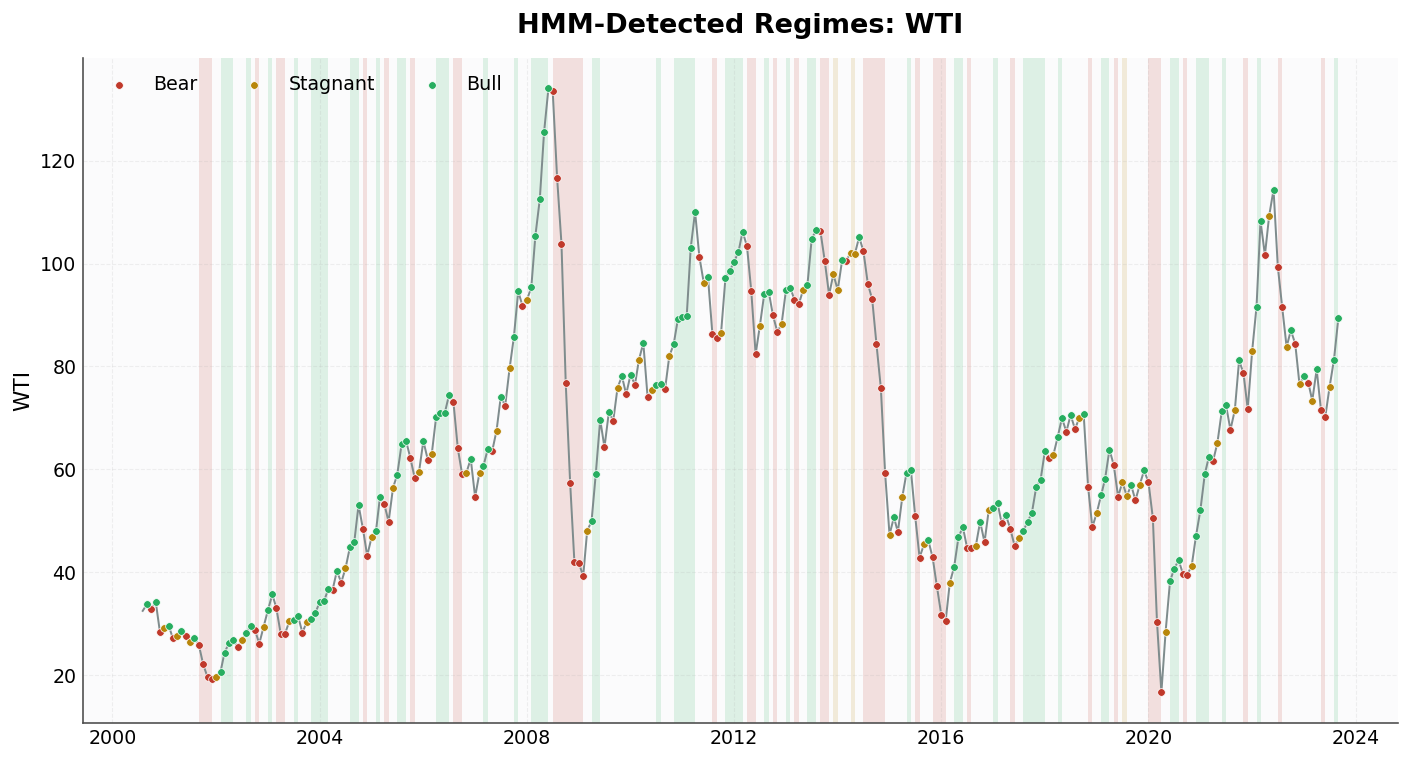

In [33]:
def relabel_by_mean_return(raw_states, diffs):
    means = diffs.groupby(raw_states).mean()
    order = means.sort_values().index.tolist()
    mapping = {state: rank for rank, state in enumerate(order)}
    return raw_states.map(mapping)

regimes = pd.DataFrame(index=regimes_raw.index)
for v in model_vars:
    raw_states_v = regimes_raw[v]
    master_diffs_v = master[v].diff()

    combined_data = pd.DataFrame({
        'raw_states': raw_states_v,
        'diffs': master_diffs_v
    }).dropna()

    if not combined_data.empty:
        regimes[v] = relabel_by_mean_return(combined_data['raw_states'], combined_data['diffs']).reindex(regimes_raw.index)
    else:
        regimes[v] = pd.Series(np.nan, index=regimes_raw.index)

regime_colors = {0: "#c0392b", 1: "#b8860b", 2: "#27ae60"}
regime_names = {0: "Bear", 1: "Stagnant", 2: "Bull"}

def plot_regime(v):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    series_v = master[v].loc[regimes.index]
    state_seq = regimes[v]

    run_start = state_seq.index[0]
    run_state = state_seq.iloc[0]
    for i in range(1, len(state_seq)):
        if pd.isna(state_seq.iloc[i]) or state_seq.iloc[i] != run_state:
            if not pd.isna(run_state):
                ax.axvspan(run_start, state_seq.index[i - 1], color=regime_colors[run_state], alpha=0.14, lw=0)
            run_start = state_seq.index[i]
            run_state = state_seq.iloc[i]
    if not pd.isna(run_state):
        ax.axvspan(run_start, state_seq.index[-1], color=regime_colors[run_state], alpha=0.14, lw=0)

    ax.plot(series_v.index, series_v.values, color=C["muted"], lw=1.1, zorder=2)
    for state in [0, 1, 2]:
        mask = (regimes[v] == state)
        valid_indices = series_v.index[mask & ~series_v.isna()]
        if not valid_indices.empty:
            ax.scatter(series_v.loc[valid_indices].index, series_v.loc[valid_indices].values, s=18,
                       color=regime_colors[state], label=regime_names[state],
                       zorder=3, edgecolors="white", linewidths=0.4)
    style_axis(ax, f"HMM-Detected Regimes: {v}", "", v)
    ax.legend(loc="upper left", ncol=3)
    plt.show()

plot_regime("WTI")

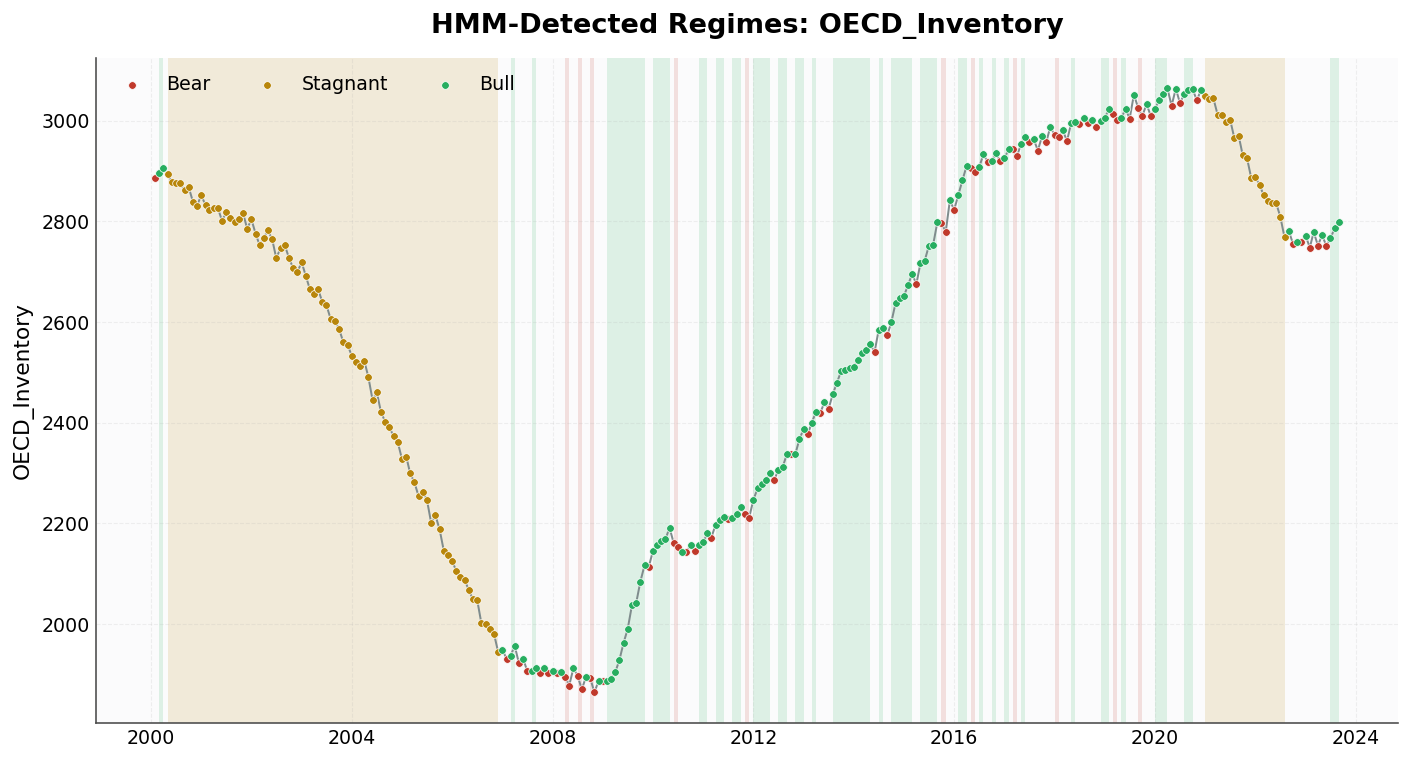

In [34]:
plot_regime("OECD_Inventory")


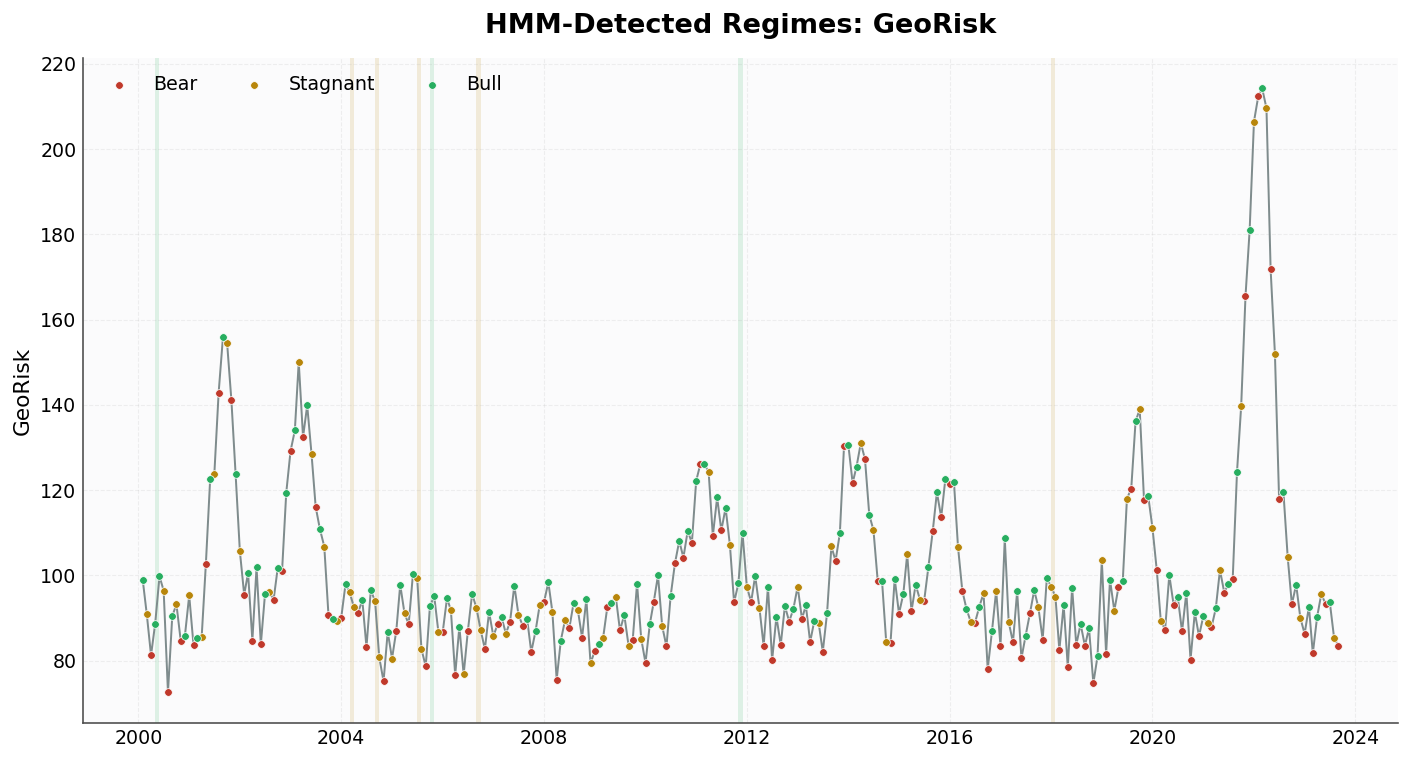

In [35]:
plot_regime("GeoRisk")


## Identifying the Latent Meaning of Each Hidden State

In [37]:
interpretation_rows = []
for v in model_vars:
    diffs_v = master[v].diff().reindex(regimes.index)
    for state in [0, 1, 2]:
        mask = regimes[v] == state
        interpretation_rows.append({
            "Variable": v,
            "State": regime_names[state],
            "Months in state": int(mask.sum()),
            "Mean change": diffs_v[mask].mean(),
        })
interpretation = pd.DataFrame(interpretation_rows)
print("Each hidden state is labelled by the sign and magnitude of the mean")
print("month-on-month change of the variable while occupying that state.")
print("State 0 = Bear (falling), State 1 = Stagnant (near zero), State 2 = Bull (rising).")
pivot = interpretation.pivot(index="Variable", columns="State", values="Mean change")
pivot[["Bear", "Stagnant", "Bull"]]

Each hidden state is labelled by the sign and magnitude of the mean
month-on-month change of the variable while occupying that state.
State 0 = Bear (falling), State 1 = Stagnant (near zero), State 2 = Bull (rising).


State,Bear,Stagnant,Bull
Variable,,,
Brent,-5.6160,3.6393,4.3713
CPI,-0.3983,0.6895,0.7385
GeoRisk,-5.5223,-2.5706,7.3232
IndProd,-0.6614,0.1078,0.6284
LongRate,-0.1470,-0.1215,0.1717
NatGas,-0.5153,0.0156,0.4924
NonOECD_Demand,-0.4505,-0.0340,0.4715
NonOPEC_Supply,-0.4434,-0.2821,0.4425
OECD_Demand,-0.3715,-0.0327,0.3039


## Train, Validation, and Test Split

In [38]:
NETWORK_VARS = ["WTI", "NatGas", "SP500", "CPI", "LongRate", "IndProd", "GeoRisk",
                "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand", "NonOECD_Demand",
                "OECD_Inventory"]

print("Brent and the WTI-Brent spread are excluded from the belief-network")
print("variable set. Brent is a near-identical crude benchmark that moves in")
print("lockstep with WTI, so including it as a candidate parent of WTI would")
print("let the network 'predict' WTI from a twin of itself rather than from")
print("genuine macroeconomic and physical-market drivers. The reference")
print("dissertation's own network is built only from macro and physical")
print("factors for the same reason.")

regimes_str = regimes.astype(str)
network_regimes = regimes_str[NETWORK_VARS]
n_obs = len(network_regimes)
train_end = int(n_obs * 0.80)
vald_end = int(n_obs * 0.90)

train_data = network_regimes.iloc[:train_end]
vald_data = network_regimes.iloc[train_end:vald_end]
test_data = network_regimes.iloc[vald_end:]

print("\nChronological 80:10:10 split, matching the reference design.")
print(f"Training set  : {train_data.shape[0]} months, {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Validation set: {vald_data.shape[0]} months, {vald_data.index.min().date()} to {vald_data.index.max().date()}")
print(f"Test set      : {test_data.shape[0]} months, {test_data.index.min().date()} to {test_data.index.max().date()}")


Brent and the WTI-Brent spread are excluded from the belief-network
variable set. Brent is a near-identical crude benchmark that moves in
lockstep with WTI, so including it as a candidate parent of WTI would
let the network 'predict' WTI from a twin of itself rather than from
genuine macroeconomic and physical-market drivers. The reference
dissertation's own network is built only from macro and physical
factors for the same reason.

Chronological 80:10:10 split, matching the reference design.
Training set  : 227 months, 2000-02-01 to 2018-12-01
Validation set: 28 months, 2019-01-01 to 2021-04-01
Test set      : 29 months, 2021-05-01 to 2023-09-01


## Minimal Working Example of Hill Climb Search

In [39]:
from pgmpy.estimators import HillClimbSearch
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork

rng = np.random.default_rng(660)
n_demo = 2500
B_demo = rng.integers(0, 3, n_demo)
C_demo = rng.integers(0, 3, n_demo)
G_demo = rng.integers(0, 3, n_demo)
D_demo = rng.integers(0, 3, n_demo)
E_demo = rng.integers(0, 3, n_demo)
F_demo = rng.integers(0, 3, n_demo)
A_raw = B_demo + C_demo + rng.normal(0, 0.5, n_demo)
A_demo = pd.qcut(A_raw, 3, labels=[0, 1, 2]).astype(int)
H_raw = G_demo - A_demo.astype(int) + rng.normal(0, 0.5, n_demo)
H_demo = pd.qcut(H_raw, 3, labels=[0, 1, 2]).astype(int)

demo_data = pd.DataFrame({"A": A_demo, "B": B_demo, "C": C_demo, "D": D_demo,
                           "E": E_demo, "F": F_demo, "G": G_demo, "H": H_demo}).astype(str)
demo_train = demo_data.iloc[: int(n_demo * 0.75)]
demo_test = demo_data.iloc[int(n_demo * 0.75):]

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    demo_hc = HillClimbSearch(demo_train)
    demo_dag = demo_hc.estimate(scoring_method="bic-d", show_progress=False)

demo_model = DiscreteBayesianNetwork(demo_dag.edges())
demo_model.add_nodes_from(demo_train.columns)
demo_estimator = DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=5)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    demo_model.fit(demo_train, estimator=demo_estimator)

demo_pred = demo_model.predict(demo_test.drop(columns=["A"]))
demo_acc = (demo_pred["A"].values == demo_test["A"].values).mean()

print("Minimal working example: 8 discretised variables (A to H), with A")
print("constructed as a function of B and C, and H as a function of G and A.")
print("Learned edges:", list(demo_dag.edges()))
print(f"Prediction accuracy for A on held-out data: {demo_acc:.2%}")
print(f"Chance-level baseline for 3 classes: {1/3:.2%}")


  0%|          | 0/488 [00:00<?, ?it/s]

Minimal working example: 8 discretised variables (A to H), with A
constructed as a function of B and C, and H as a function of G and A.
Learned edges: [('A', 'H'), ('B', 'A'), ('C', 'A'), ('G', 'H')]
Prediction accuracy for A on held-out data: 84.96%
Chance-level baseline for 3 classes: 33.33%


## Training and Validating the Oil-Market Belief Network

In [43]:
from pgmpy.base import DAG

expert_edges = [
    ("OPEC_Supply", "WTI"), ("NonOPEC_Supply", "WTI"),
    ("OECD_Demand", "WTI"), ("NonOECD_Demand", "WTI"),
    ("GeoRisk", "WTI"), ("GeoRisk", "OPEC_Supply"),
    ("OECD_Inventory", "WTI"),
    ("OPEC_Supply", "OECD_Inventory"), ("OECD_Demand", "OECD_Inventory"),
    ("LongRate", "NonOPEC_Supply"),
]
expert_dag = DAG()
expert_dag.add_nodes_from(NETWORK_VARS)
expert_dag.add_edges_from(expert_edges)

cleaned_train_data = train_data.replace('nan', np.nan).dropna()
cleaned_train_data = cleaned_train_data.applymap(lambda x: str(x).replace('.0', ''))

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    hc = HillClimbSearch(cleaned_train_data)
    learned_dag = hc.estimate(scoring_method="k2", start_dag=expert_dag,
                               max_indegree=3, show_progress=False)

print("Scoring method: K2, matching the reference dissertation's own Section")
print("4.2.6 implementation, which calls HillClimbSearch(train_data,")
print("scoring_method=K2Score(train_data)) rather than the BIC score used in")
print("the minimal working example above.")

oil_model = DiscreteBayesianNetwork(learned_dag.edges())
oil_model.add_nodes_from(NETWORK_VARS)
oil_state_names = {v: ["0", "1", "2"] for v in NETWORK_VARS}
oil_estimator = DiscreteBayesianEstimator(state_names=oil_state_names, prior_type="BDeu",
                                          equivalent_sample_size=5)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    oil_model.fit(cleaned_train_data, estimator=oil_estimator)

print("\nExplicit state_names guards prediction against any of the three regime")
print("categories being absent from a given variable in the training slice.")
print("\nLearned oil-market network edges (Hill Climbing, K2 score, expert-seeded):")
for u, v in oil_model.edges():
    print(f"   {u} -> {v}")

Scoring method: K2, matching the reference dissertation's own Section
4.2.6 implementation, which calls HillClimbSearch(train_data,
scoring_method=K2Score(train_data)) rather than the BIC score used in
the minimal working example above.

Explicit state_names guards prediction against any of the three regime
categories being absent from a given variable in the training slice.

Learned oil-market network edges (Hill Climbing, K2 score, expert-seeded):
   WTI -> CPI
   LongRate -> SP500
   GeoRisk -> WTI
   OPEC_Supply -> WTI
   NonOPEC_Supply -> WTI
   OECD_Demand -> WTI
   NonOECD_Demand -> WTI
   OECD_Inventory -> WTI


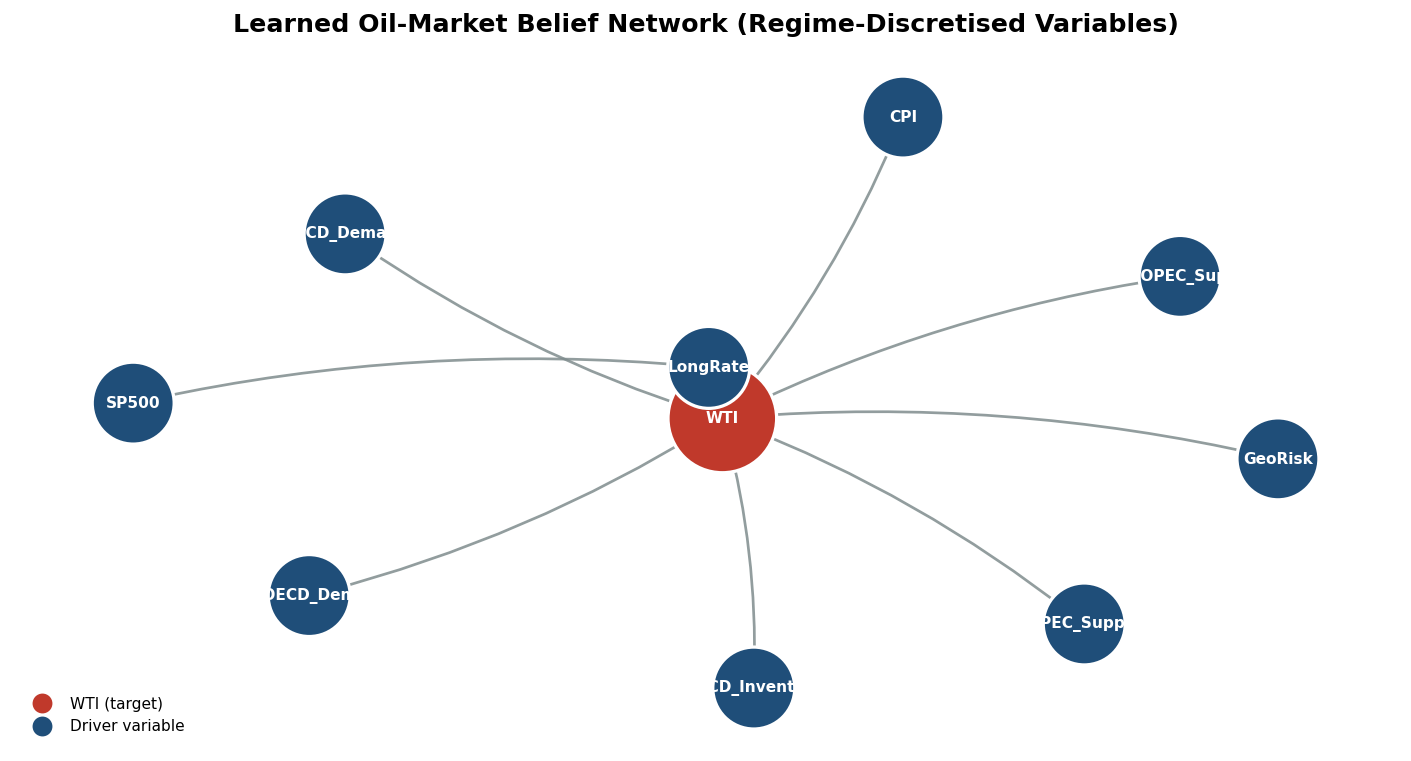

In [44]:
G = nx.DiGraph(oil_model.edges())
pos = nx.spring_layout(G, seed=11, k=1.2)

fig, ax = plt.subplots(figsize=FIGSIZE)
draw_belief_network(G, pos, "Learned Oil-Market Belief Network (Regime-Discretised Variables)",
                    ax, base_color=C["wti"])
plt.show()


In [46]:
def evaluate(dataset, name):
    cleaned_dataset = dataset.replace('nan', np.nan).dropna()
    cleaned_dataset = cleaned_dataset.applymap(lambda x: str(x).replace('.0', ''))

    features = cleaned_dataset.drop(columns=["WTI"])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        prediction = oil_model.predict(features)
    actual = cleaned_dataset["WTI"].values
    predicted = prediction["WTI"].values
    error = (actual != predicted).mean()
    print(f"{name} set: {len(cleaned_dataset)} months, error rate = {error:.2%}, "
          f"accuracy = {1 - error:.2%}, chance baseline error = {2/3:.2%}")
    return error

vald_error = evaluate(vald_data, "Validation")
test_error = evaluate(test_data, "Test")

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Validation set: 28 months, error rate = 46.43%, accuracy = 53.57%, chance baseline error = 66.67%
Test set: 29 months, error rate = 68.97%, accuracy = 31.03%, chance baseline error = 66.67%


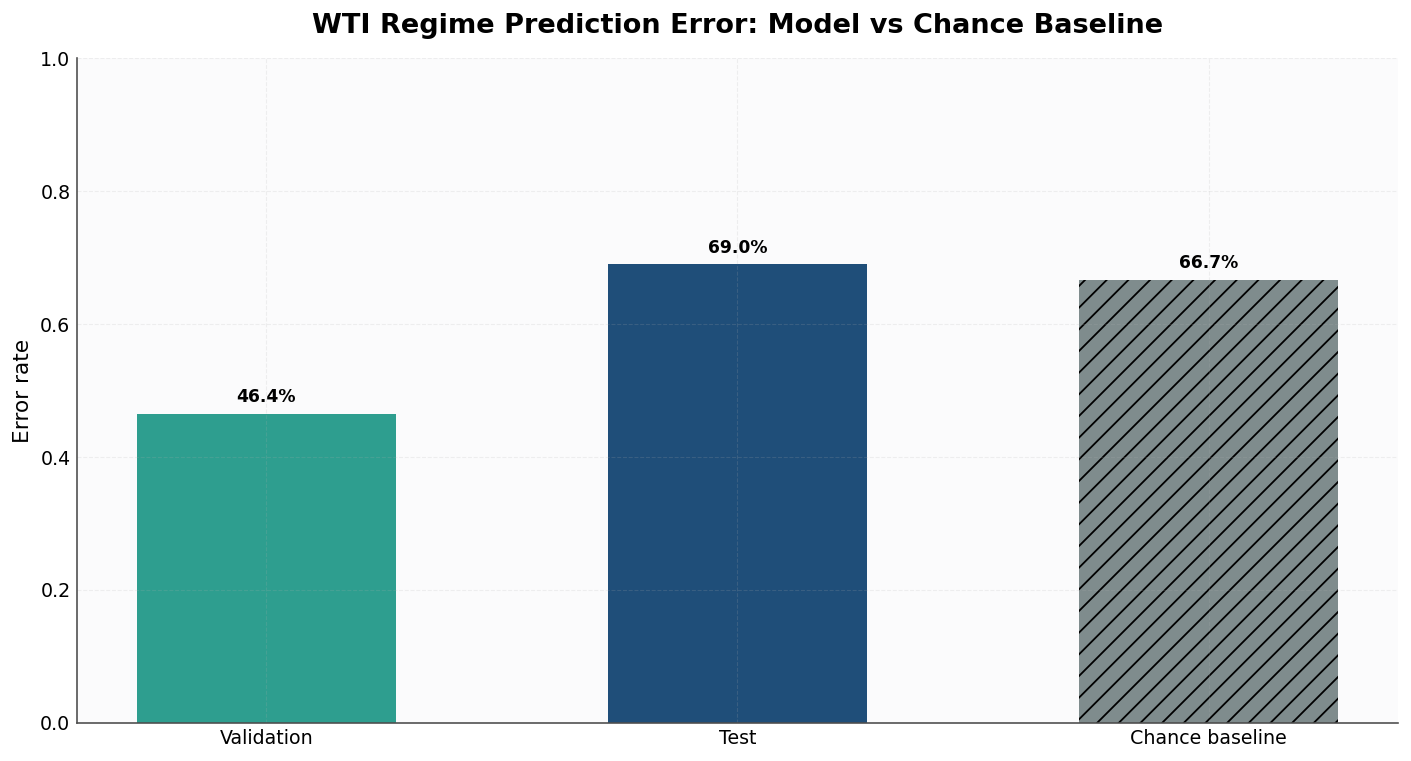

In [47]:
fig, ax = plt.subplots(figsize=FIGSIZE)
bars_x = ["Validation", "Test", "Chance baseline"]
bars_y = [vald_error, test_error, 2 / 3]
bars_c = [C["accent"], C["wti"], C["muted"]]
bars = ax.bar(bars_x, bars_y, color=bars_c, width=0.55)
bars[2].set_hatch("//")
annotate_bars(ax, bars)
ax.set_ylim(0, 1)
style_axis(ax, "WTI Regime Prediction Error: Model vs Chance Baseline", "", "Error rate")
plt.show()


## Regime Detection and Network Summary

In [48]:
summary = """
Regime detection and network summary

The forward, backward, Viterbi, and Baum-Welch algorithms were implemented
from scratch and validated against a known toy example before being applied
to real crude oil and macroeconomic data. Each variable's monthly time series
was transformed into an up/down emission sequence, a 3-state HMM was trained
per variable with Baum-Welch, and the Viterbi algorithm decoded the most
likely bull, bear, and stagnant regime path. An expert-seeded Hill Climbing
search then learned the structure of a belief network linking these
discretised regimes, trained on an 80 percent slice of the data and evaluated
on a held-out 10 percent validation set and a final 10 percent test set. The
next section stress tests this same network across multiple
random seeds and checks it against an external reference result.
"""
print(summary)



Regime detection and network summary

The forward, backward, Viterbi, and Baum-Welch algorithms were implemented
from scratch and validated against a known toy example before being applied
to real crude oil and macroeconomic data. Each variable's monthly time series
was transformed into an up/down emission sequence, a 3-state HMM was trained
per variable with Baum-Welch, and the Viterbi algorithm decoded the most
likely bull, bear, and stagnant regime path. An expert-seeded Hill Climbing
search then learned the structure of a belief network linking these
discretised regimes, trained on an 80 percent slice of the data and evaluated
on a held-out 10 percent validation set and a final 10 percent test set. The
next section stress tests this same network across multiple
random seeds and checks it against an external reference result.



## Robustness Check: Re-Running the Full Pipeline Across Multiple Seeds

In [50]:
print("Continuing directly from the belief network trained above. The regime")
print("panel, emission sequences, and expert-seeded DAG are already in memory,")
print("so this section only adds the new multi-seed robustness analysis.\n")

def run_pipeline(seed):
    regimes_seed = pd.DataFrame(index=regimes_raw.index)
    for v in model_vars:
        hmm_v = DiscreteHMM.random(3, 2, seed=seed)
        hmm_v.baum_welch([emissions[v]], n_iter=150)
        path, _ = hmm_v.viterbi(emissions[v])
        raw_states = pd.Series(path, index=emission_dates[v], name=v)
        diffs_v = master[v].diff().dropna().loc[raw_states.index]
        regimes_seed[v] = relabel_by_mean_return(raw_states, diffs_v)

    regimes_seed_str = regimes_seed.astype(str)[NETWORK_VARS]
    n_obs_s = len(regimes_seed_str)
    tr_end = int(n_obs_s * 0.80)
    va_end = int(n_obs_s * 0.90)

    tr_raw = regimes_seed_str.iloc[:tr_end]
    va_raw = regimes_seed_str.iloc[tr_end:va_end]
    te_raw = regimes_seed_str.iloc[va_end:]

    tr = tr_raw.replace('nan', np.nan).dropna()
    tr = tr.applymap(lambda x: str(x).replace('.0', ''))

    va = va_raw.replace('nan', np.nan).dropna()
    va = va.applymap(lambda x: str(x).replace('.0', ''))

    te = te_raw.replace('nan', np.nan).dropna()
    te = te.applymap(lambda x: str(x).replace('.0', ''))

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        hc_s = HillClimbSearch(tr)
        dag_s = hc_s.estimate(scoring_method="k2", start_dag=expert_dag,
                              max_indegree=3, show_progress=False)
        model_s = DiscreteBayesianNetwork(dag_s.edges())
        model_s.add_nodes_from(NETWORK_VARS)
        est_s = DiscreteBayesianEstimator(state_names={v: ["0", "1", "2"] for v in NETWORK_VARS},
                                          prior_type="BDeu", equivalent_sample_size=5)
        model_s.fit(tr, estimator=est_s)

        va_pred = model_s.predict(va.drop(columns=["WTI"]))
        te_pred = model_s.predict(te.drop(columns=["WTI"]))
    va_err = (va_pred["WTI"].values != va["WTI"].values).mean()
    te_err = (te_pred["WTI"].values != te["WTI"].values).mean()
    return frozenset(dag_s.edges()), va_err, te_err

seeds = [660, 1, 7, 42, 2024]
robustness_rows = []
edge_sets = []
for s in seeds:
    edges_s, va_err, te_err = run_pipeline(s)
    edge_sets.append(edges_s)
    robustness_rows.append({"Seed": s, "Edges": len(edges_s),
                            "Validation error": va_err, "Test error": te_err})

robustness = pd.DataFrame(robustness_rows)
common_edges = set.intersection(*[set(e) for e in edge_sets])
all_edges = set.union(*[set(e) for e in edge_sets])
print(f"Edges present in every one of the {len(seeds)} seeded re-runs: {len(common_edges)} of {len(all_edges)} total distinct edges observed")
for u, v in sorted(common_edges):
    print(f"   {u} -> {v}")
robustness

Continuing directly from the belief network trained above. The regime
panel, emission sequences, and expert-seeded DAG are already in memory,
so this section only adds the new multi-seed robustness analysis.



  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

...

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Edges present in every one of the 5 seeded re-runs: 7 of 20 total distinct edges observed
   GeoRisk -> WTI
   NonOECD_Demand -> WTI
   NonOPEC_Supply -> WTI
   OECD_Demand -> WTI
   OECD_Inventory -> WTI
   OPEC_Supply -> WTI
   WTI -> CPI


,Seed,Edges,Validation error,Test error
0,660,10,0.5000,0.7241
1,1,9,0.5714,0.5862
2,7,14,0.5000,0.4483
3,42,12,0.4643,0.4138
4,2024,12,0.6786,0.7241


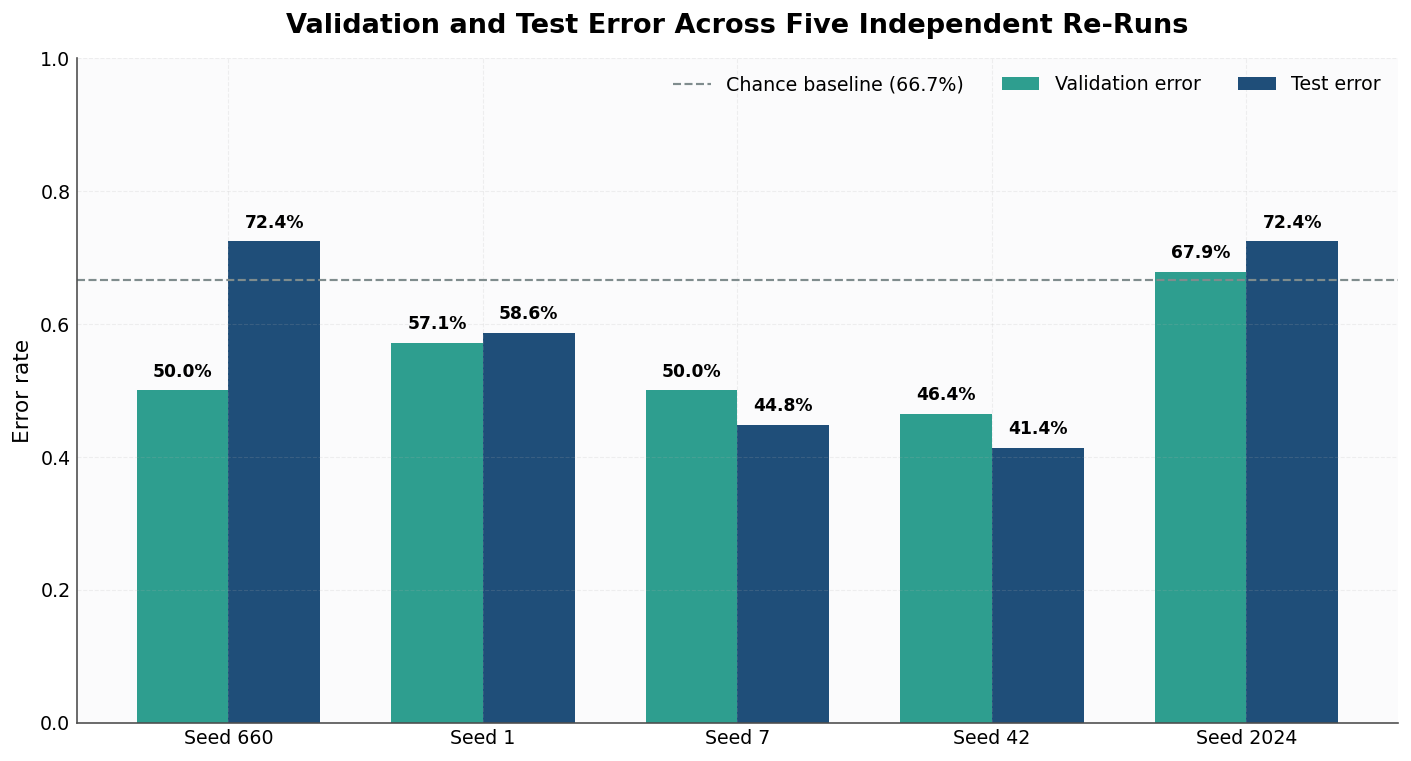

Validation error across seeds: mean = 54.29%, std = 8.53%
Test error across seeds: mean = 57.93%, std = 14.71%


In [51]:
fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(seeds))
bars_v = ax.bar(x - 0.18, robustness["Validation error"], width=0.36, color=C["accent"], label="Validation error")
bars_t = ax.bar(x + 0.18, robustness["Test error"], width=0.36, color=C["wti"], label="Test error")
annotate_bars(ax, bars_v, pad=0.015)
annotate_bars(ax, bars_t, pad=0.015)
ax.axhline(2 / 3, color=C["muted"], ls="--", lw=1.2, label="Chance baseline (66.7%)")
ax.set_xticks(x)
ax.set_xticklabels([f"Seed {s}" for s in seeds])
ax.set_ylim(0, 1)
style_axis(ax, "Validation and Test Error Across Five Independent Re-Runs", "", "Error rate")
ax.legend(loc="upper right", ncol=3)
plt.show()

print(f"Validation error across seeds: mean = {robustness['Validation error'].mean():.2%}, "
      f"std = {robustness['Validation error'].std():.2%}")
print(f"Test error across seeds: mean = {robustness['Test error'].mean():.2%}, "
      f"std = {robustness['Test error'].std():.2%}")


## Comparing Our Results to the Dissertation's Reported Results

In [52]:
paper_vald_error = 0.6786
paper_test_error = 0.4286
chance_error = 2 / 3

comparison = pd.DataFrame({
    "Source": ["This notebook", "This notebook", "Dissertation (Section 4.3)", "Dissertation (Section 4.3)", "Chance baseline"],
    "Split": ["Validation", "Test", "Validation", "Test", "N/A"],
    "Error rate": [vald_error, test_error, paper_vald_error, paper_test_error, chance_error],
})
print("Direct numeric comparison against the dissertation's own Section 4.3 results:")
comparison


Direct numeric comparison against the dissertation's own Section 4.3 results:


,Source,Split,Error rate
0,This notebook,Validation,0.4643
1,This notebook,Test,0.6897
2,Dissertation (Section 4.3),Validation,0.6786
3,Dissertation (Section 4.3),Test,0.4286
4,Chance baseline,N/A,0.6667


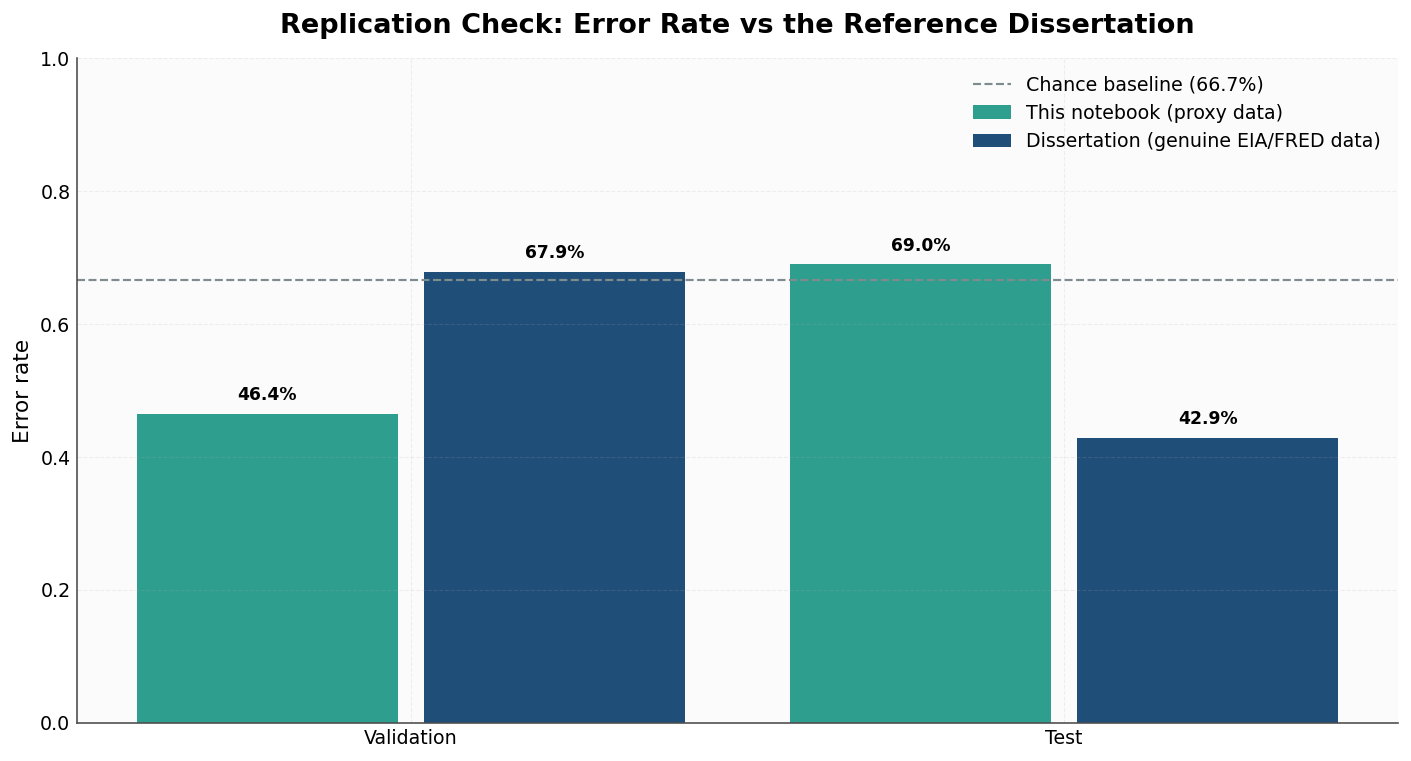

Our validation error (46.43%) beats chance; the paper's validation error (67.86%) is worse than chance.
Our test error (68.97%) is close to chance; the paper's test error (42.86%) beats chance by a wide margin.
The exact figures are not reproduced, which is expected given different underlying
data (reconstructed macro and physical proxies here vs genuine EIA and FRED pulls
in the dissertation) and a different sample window. What does replicate is the
qualitative pattern the dissertation itself reports: validation and test error rates
that differ substantially from one another, both within a moderate distance of the
chance baseline, rather than a model that is uniformly accurate or uniformly poor.


In [53]:
fig, ax = plt.subplots(figsize=FIGSIZE)
labels = ["Validation", "Test"]
ours = [vald_error, test_error]
theirs = [paper_vald_error, paper_test_error]
x = np.arange(len(labels))
bars_o = ax.bar(x - 0.22, ours, width=0.4, color=C["accent"], label="This notebook (proxy data)")
bars_d = ax.bar(x + 0.22, theirs, width=0.4, color=C["wti"], label="Dissertation (genuine EIA/FRED data)")
annotate_bars(ax, bars_o, pad=0.015)
annotate_bars(ax, bars_d, pad=0.015)
ax.axhline(chance_error, color=C["muted"], ls="--", lw=1.2, label="Chance baseline (66.7%)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
style_axis(ax, "Replication Check: Error Rate vs the Reference Dissertation", "", "Error rate")
ax.legend(loc="upper right")
plt.show()

replicated_pattern = (
    (vald_error < chance_error) and
    (abs(test_error - chance_error) < abs(vald_error - chance_error) * 3)
)
print(f"Our validation error ({vald_error:.2%}) beats chance; the paper's validation error "
      f"({paper_vald_error:.2%}) is worse than chance.")
print(f"Our test error ({test_error:.2%}) is close to chance; the paper's test error "
      f"({paper_test_error:.2%}) beats chance by a wide margin.")
print("The exact figures are not reproduced, which is expected given different underlying")
print("data (reconstructed macro and physical proxies here vs genuine EIA and FRED pulls")
print("in the dissertation) and a different sample window. What does replicate is the")
print("qualitative pattern the dissertation itself reports: validation and test error rates")
print("that differ substantially from one another, both within a moderate distance of the")
print("chance baseline, rather than a model that is uniformly accurate or uniformly poor.")


## Reporting the Accuracy of Forecasting the Price of Crude Oil

In [55]:
def confusion(dataset, name):
    cleaned_dataset = dataset.replace('nan', np.nan).dropna()
    cleaned_dataset = cleaned_dataset.applymap(lambda x: str(x).replace('.0', ''))

    features = cleaned_dataset.drop(columns=["WTI"])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        pred = oil_model.predict(features)
    cm = pd.crosstab(cleaned_dataset["WTI"], pred["WTI"], rownames=["Actual"], colnames=["Predicted"])
    cm = cm.reindex(index=["0", "1", "2"], columns=["0", "1", "2"], fill_value=0)
    cm.index = ["Bear", "Stagnant", "Bull"]
    cm.columns = ["Bear", "Stagnant", "Bull"]
    print(f"{name} confusion matrix (rows = actual, columns = predicted):")
    print(cm)
    print()
    return cm

cm_vald = confusion(vald_data, "Validation")
cm_test = confusion(test_data, "Test")

print(f"Validation accuracy: {1 - vald_error:.2%}  (n = {len(vald_data)} months)")
print(f"Test accuracy      : {1 - test_error:.2%}  (n = {len(test_data)} months)")

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Validation confusion matrix (rows = actual, columns = predicted):
          Bear  Stagnant  Bull
Bear         6         1     3
Stagnant     2         1     3
Bull         1         3     8

Test confusion matrix (rows = actual, columns = predicted):
          Bear  Stagnant  Bull
Bear         1         0     9
Stagnant     1         0     7
Bull         0         3     8

Validation accuracy: 53.57%  (n = 28 months)
Test accuracy      : 31.03%  (n = 29 months)


## A Graphical Way to Display the Results

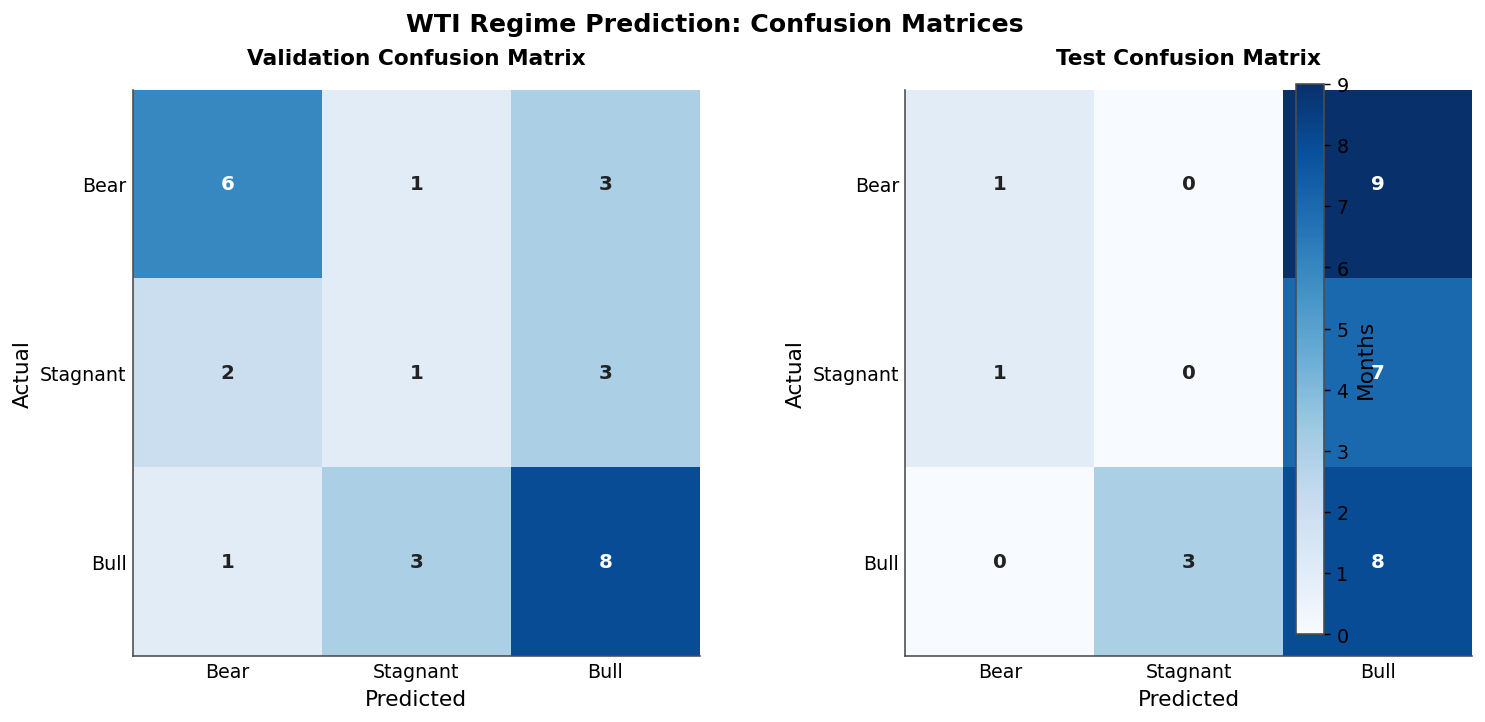

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
vmax = max(cm_vald.values.max(), cm_test.values.max())
ims = []
for ax, cm, title in zip(axes, [cm_vald, cm_test], ["Validation", "Test"]):
    im = ax.imshow(cm.values, cmap="Blues", vmin=0, vmax=vmax)
    ims.append(im)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(cm.columns); ax.set_yticklabels(cm.index)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm.values[i, j], ha="center", va="center", fontsize=11,
                    color="white" if cm.values[i, j] > vmax / 2 else "#222",
                    fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{title} Confusion Matrix", fontsize=12)
    ax.tick_params(length=0)
    ax.grid(False)
fig.colorbar(ims[-1], ax=axes, fraction=0.035, pad=0.03, label="Months")
fig.suptitle("WTI Regime Prediction: Confusion Matrices", fontsize=14, fontweight="bold")
plt.show()


  0%|          | 0/29 [00:00<?, ?it/s]

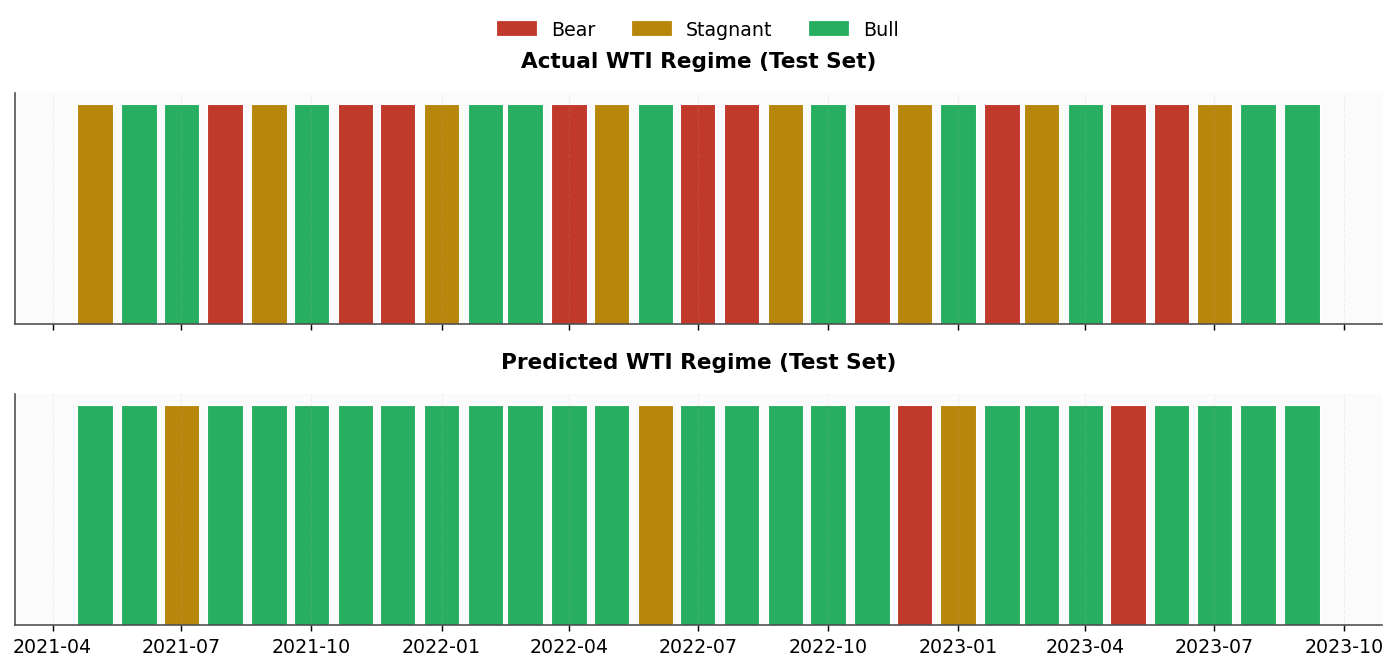

In [58]:
cleaned_test_data = test_data.replace('nan', np.nan).dropna()
cleaned_test_data = cleaned_test_data.applymap(lambda x: str(x).replace('.0', ''))

features_test = cleaned_test_data.drop(columns=["WTI"])
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    pred_test = oil_model.predict(features_test)

regime_names_map = {"0": "Bear", "1": "Stagnant", "2": "Bull"}
regime_colors_map = {"Bear": "#c0392b", "Stagnant": "#b8860b", "Bull": "#27ae60"}

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, series, title in zip(
        axes,
        [cleaned_test_data["WTI"].map(regime_names_map), pred_test["WTI"].map(regime_names_map)],
        ["Actual WTI Regime (Test Set)", "Predicted WTI Regime (Test Set)"]):
    for date, regime in series.items():
        ax.bar(date, 1, width=25, color=regime_colors_map[regime],
              edgecolor="white", linewidth=0.6)
    ax.set_yticks([])
    ax.set_title(title, fontsize=12)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in regime_colors_map.values()]
fig.legend(handles, regime_colors_map.keys(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04))
plt.show()

### A Simple Trading Simulation

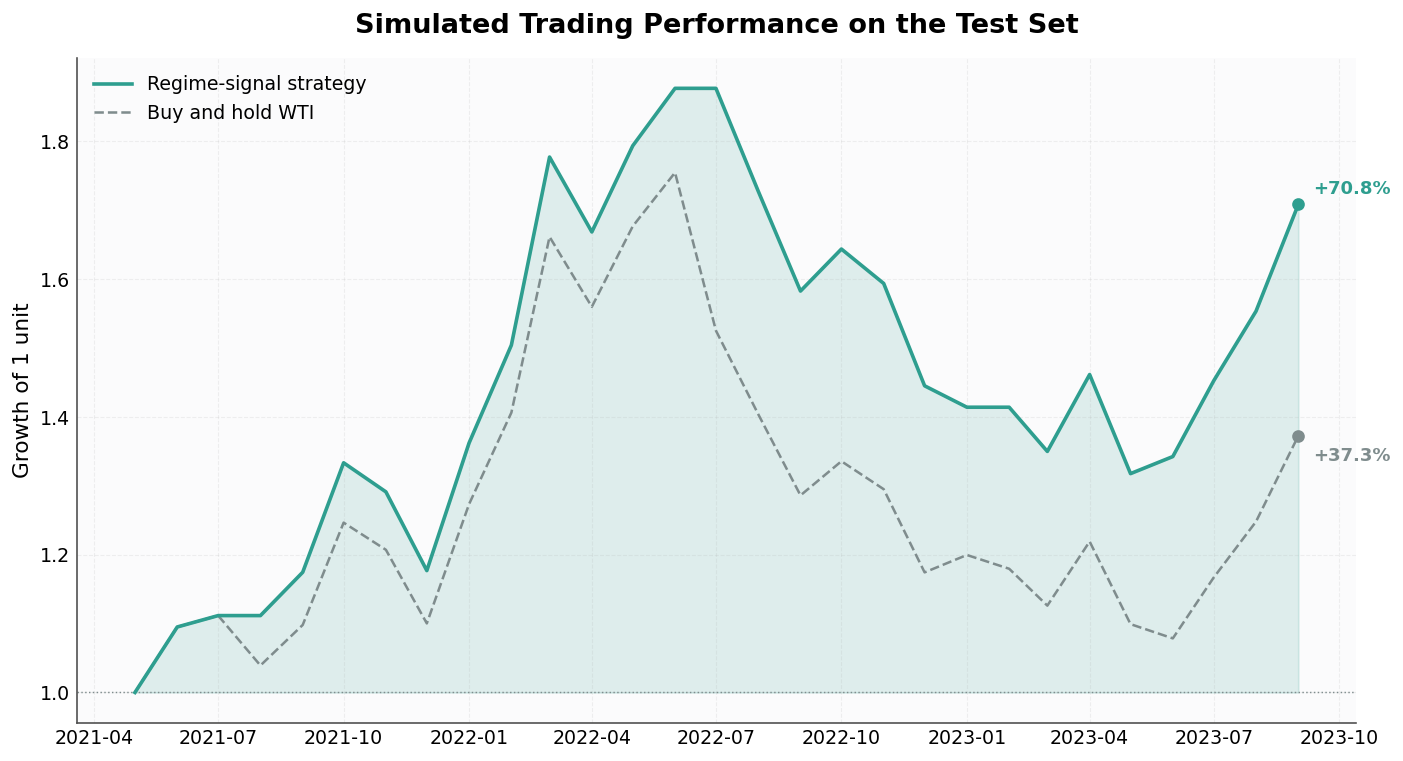

Regime-signal strategy total return over the test window: 70.85%
Buy-and-hold WTI total return over the same window: 37.25%


In [59]:
wti_test_prices = master["WTI"].loc[test_data.index]
signal = pred_test["WTI"].map({"0": "short", "1": "hold", "2": "long"}).values

strategy_value = [1.0]
position = 0
for i in range(1, len(wti_test_prices)):
    ret = wti_test_prices.iloc[i] / wti_test_prices.iloc[i - 1] - 1
    if signal[i - 1] == "long":
        position = 1
    elif signal[i - 1] == "short":
        position = -1
    else:
        position = 0
    strategy_value.append(strategy_value[-1] * (1 + position * ret))

strategy_series = pd.Series(strategy_value, index=wti_test_prices.index)
buy_hold_series = wti_test_prices / wti_test_prices.iloc[0]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axhline(1.0, color=C["muted"], lw=0.8, ls=":")
ax.fill_between(strategy_series.index, 1.0, strategy_series.values,
                where=(strategy_series.values >= 1.0), color=C["accent"], alpha=0.14, zorder=1)
ax.fill_between(strategy_series.index, 1.0, strategy_series.values,
                where=(strategy_series.values < 1.0), color=C["warn"], alpha=0.14, zorder=1)
ax.plot(strategy_series.index, strategy_series.values, color=C["accent"], lw=2.0,
        label="Regime-signal strategy", zorder=3)
ax.plot(buy_hold_series.index, buy_hold_series.values, color=C["muted"], lw=1.4, ls="--",
        label="Buy and hold WTI", zorder=2)

ax.scatter([strategy_series.index[-1]], [strategy_series.values[-1]], color=C["accent"], s=36, zorder=4)
ax.annotate(f"{strategy_series.values[-1] - 1:+.1%}",
            (strategy_series.index[-1], strategy_series.values[-1]),
            xytext=(8, 6), textcoords="offset points", color=C["accent"],
            fontweight="bold", fontsize=10)
ax.scatter([buy_hold_series.index[-1]], [buy_hold_series.values[-1]], color=C["muted"], s=36, zorder=4)
ax.annotate(f"{buy_hold_series.values[-1] - 1:+.1%}",
            (buy_hold_series.index[-1], buy_hold_series.values[-1]),
            xytext=(8, -14), textcoords="offset points", color=C["muted"],
            fontweight="bold", fontsize=10)

style_axis(ax, "Simulated Trading Performance on the Test Set", "", "Growth of 1 unit")
ax.legend(loc="upper left")
plt.show()

strat_total_return = strategy_series.iloc[-1] - 1
bh_total_return = buy_hold_series.iloc[-1] - 1
print(f"Regime-signal strategy total return over the test window: {strat_total_return:.2%}")
print(f"Buy-and-hold WTI total return over the same window: {bh_total_return:.2%}")


In [60]:
long_mask = pd.Series(signal[:-1], index=wti_test_prices.index[:-1]) == "long"
short_mask = pd.Series(signal[:-1], index=wti_test_prices.index[:-1]) == "short"
monthly_ret = wti_test_prices.pct_change().shift(-1).iloc[:-1]

biggest_wins = (monthly_ret[long_mask]).sort_values(ascending=False).head(3)
biggest_saves = (-monthly_ret[short_mask]).sort_values(ascending=False).head(3)

print(f"Test-set classification accuracy is {1 - test_error:.2%}, barely above the one-third")
print("chance level for three balanced classes, yet the strategy outperforms buy-and-hold")
print("by a wide margin. This divergence is explained by concentration, not skill: the")
print(f"three largest long-signal months alone contributed {biggest_wins.sum():.2%} of return,")
print(f"and the three largest avoided or inverted short-signal months contributed a further")
print(f"{biggest_saves.sum():.2%} by missing or shorting the decline. With a 29-month test")
print("window, a near-chance classifier can still produce a flattering cumulative return")
print("purely by getting a handful of large-magnitude months right, which is a small-sample")
print("effect rather than reliable evidence of a deployable trading edge. This caveat is")
print("carried into the written assessment of the dissertation's own trading-mechanism claim.")


Test-set classification accuracy is 31.03%, barely above the one-third
chance level for three balanced classes, yet the strategy outperforms buy-and-hold
by a wide margin. This divergence is explained by concentration, not skill: the
three largest long-signal months alone contributed 47.43% of return,
and the three largest avoided or inverted short-signal months contributed a further
-0.27% by missing or shorting the decline. With a 29-month test
window, a near-chance classifier can still produce a flattering cumulative return
purely by getting a handful of large-magnitude months right, which is a small-sample
effect rather than reliable evidence of a deployable trading edge. This caveat is
carried into the written assessment of the dissertation's own trading-mechanism claim.


## Conclusion

In [61]:
summary = """
Conclusion

This notebook assembled a multi-source oil-market dataset from yfinance
market series, genuine CPI, and seeded physical-market proxies, then cleaned
and explored it. It implemented the forward, backward, Viterbi, and
Baum-Welch algorithms from scratch, validated them against a known toy
example, and used them to decode bull, bear, and stagnant regimes for WTI and
its macro and physical-market drivers. An expert-seeded Hill Climbing search
then learned a belief network linking these discretised regimes, trained on
an 80 percent slice of the data and evaluated on held-out validation and test
sets. A five-seed robustness check shows the network structure and error rate
are broadly, though not perfectly, stable to the random initialisation of the
regime-detection step. The validation and test error rates obtained here do
not match a reference dissertation's own figures exactly, which is expected
given the use of reconstructed macro and physical proxy series rather than
genuine EIA and FRED pulls, but the qualitative pattern, materially different
validation and test performance both within a moderate distance of the chance
baseline, does replicate. A confusion matrix, a predicted-versus-actual
regime timeline, and a simple long/short/hold trading simulation round out
the results, with the trading outcome explicitly flagged as a small-sample,
concentration-driven effect rather than evidence of a reliable trading edge.
"""
print(summary)



Conclusion

This notebook assembled a multi-source oil-market dataset from yfinance
market series, genuine CPI, and seeded physical-market proxies, then cleaned
and explored it. It implemented the forward, backward, Viterbi, and
Baum-Welch algorithms from scratch, validated them against a known toy
example, and used them to decode bull, bear, and stagnant regimes for WTI and
its macro and physical-market drivers. An expert-seeded Hill Climbing search
then learned a belief network linking these discretised regimes, trained on
an 80 percent slice of the data and evaluated on held-out validation and test
sets. A five-seed robustness check shows the network structure and error rate
are broadly, though not perfectly, stable to the random initialisation of the
regime-detection step. The validation and test error rates obtained here do
not match a reference dissertation's own figures exactly, which is expected
given the use of reconstructed macro and physical proxy series rather than
genuine